In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("PART 1: CLASSIFICATION - BREAST CANCER DIAGNOSIS")
print("=" * 60)

PART 1: CLASSIFICATION - BREAST CANCER DIAGNOSIS


In [2]:
cancer = load_breast_cancer()
X_cancer, y_cancer = cancer.data, cancer.target

print(f"\nDataset Shape: {X_cancer.shape}")
print(f"Features: {cancer.feature_names[:]}")
print(f"Classes: {cancer.target_names}")
print(f"Class Distribution: Malignant={sum(y_cancer==0)}, Benign={sum(y_cancer==1)}")

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.3, random_state=42
)


Dataset Shape: (569, 30)
Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Classes: ['malignant' 'benign']
Class Distribution: Malignant=212, Benign=357


In [3]:
print("\n" + "=" * 60)
print("COMPARING DECISION TREE DEPTHS")
print("=" * 60)

depths = [1, 3, 5, 10, 20, None]
results_c = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    
    start_time = time.time()
    dt.fit(X_train_c, y_train_c)
    train_time = (time.time() - start_time) * 1000
    
    train_pred = dt.predict(X_train_c)
    test_pred = dt.predict(X_test_c)
    
    train_acc = accuracy_score(y_train_c, train_pred)
    test_acc = accuracy_score(y_test_c, test_pred)
    
    results_c.append({
        'depth': depth if depth else 'None',
        'train_acc': train_acc,
        'test_acc': test_acc,
        'time': train_time
    })
    
    print(f"\nMax Depth: {depth if depth else 'Unlimited'}")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy:  {test_acc:.4f}")
    print(f"  Training Time:  {train_time:.2f} ms")
    print(f"  Tree Depth:     {dt.get_depth()}")
    print(f"  Num Leaves:     {dt.get_n_leaves()}")


COMPARING DECISION TREE DEPTHS

Max Depth: 1
  Train Accuracy: 0.9246
  Test Accuracy:  0.8947
  Training Time:  15.30 ms
  Tree Depth:     1
  Num Leaves:     2

Max Depth: 3
  Train Accuracy: 0.9698
  Test Accuracy:  0.9649
  Training Time:  3.78 ms
  Tree Depth:     3
  Num Leaves:     8

Max Depth: 5
  Train Accuracy: 0.9950
  Test Accuracy:  0.9532
  Training Time:  5.66 ms
  Tree Depth:     5
  Num Leaves:     13

Max Depth: 10
  Train Accuracy: 1.0000
  Test Accuracy:  0.9415
  Training Time:  4.84 ms
  Tree Depth:     7
  Num Leaves:     16

Max Depth: 20
  Train Accuracy: 1.0000
  Test Accuracy:  0.9415
  Training Time:  4.87 ms
  Tree Depth:     7
  Num Leaves:     16

Max Depth: Unlimited
  Train Accuracy: 1.0000
  Test Accuracy:  0.9415
  Training Time:  5.43 ms
  Tree Depth:     7
  Num Leaves:     16



OVERFITTING ANALYSIS


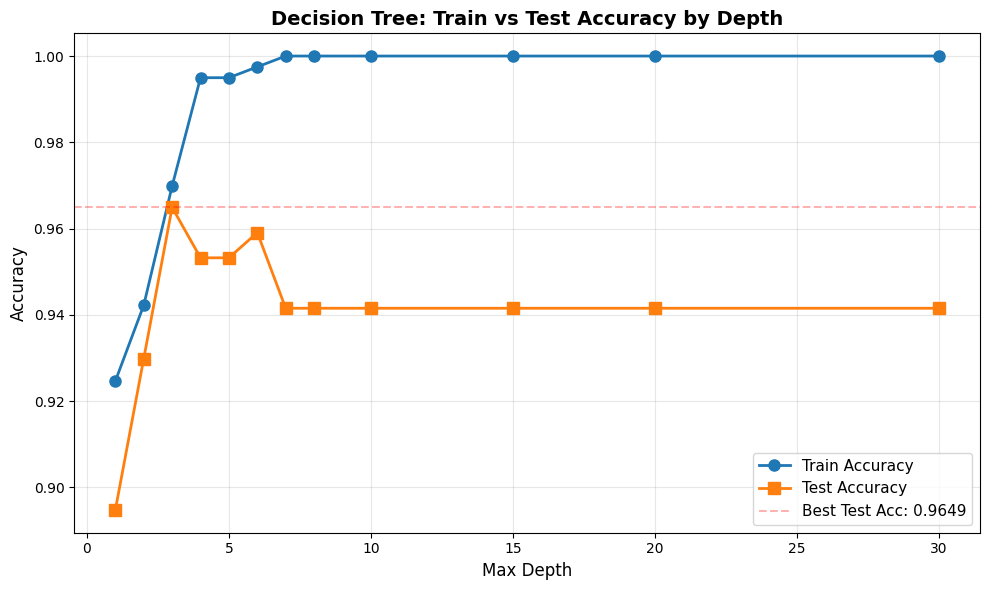


Best Test Accuracy: 0.9649 at depth 3
Overfitting starts around depth 3


In [4]:
print("\n" + "=" * 60)
print("OVERFITTING ANALYSIS")
print("=" * 60)

depth_values = [1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 20, 30]
train_accs = []
test_accs = []

for depth in depth_values:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_c, y_train_c)
    train_accs.append(accuracy_score(y_train_c, dt.predict(X_train_c)))
    test_accs.append(accuracy_score(y_test_c, dt.predict(X_test_c)))

plt.figure(figsize=(10, 6))
plt.plot(depth_values, train_accs, 'o-', label='Train Accuracy', linewidth=2, markersize=8)
plt.plot(depth_values, test_accs, 's-', label='Test Accuracy', linewidth=2, markersize=8)
plt.axhline(y=max(test_accs), color='r', linestyle='--', alpha=0.3, label=f'Best Test Acc: {max(test_accs):.4f}')
plt.xlabel('Max Depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Decision Tree: Train vs Test Accuracy by Depth', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBest Test Accuracy: {max(test_accs):.4f} at depth {depth_values[np.argmax(test_accs)]}")
print(f"Overfitting starts around depth {depth_values[np.argmax(test_accs)]}")



FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features:
1. mean concave points: 0.7197
2. worst texture: 0.1200
3. worst radius: 0.0403
4. worst area: 0.0374
5. worst perimeter: 0.0313
6. texture error: 0.0248
7. area error: 0.0138
8. worst smoothness: 0.0107
9. smoothness error: 0.0020
10. mean area: 0.0000


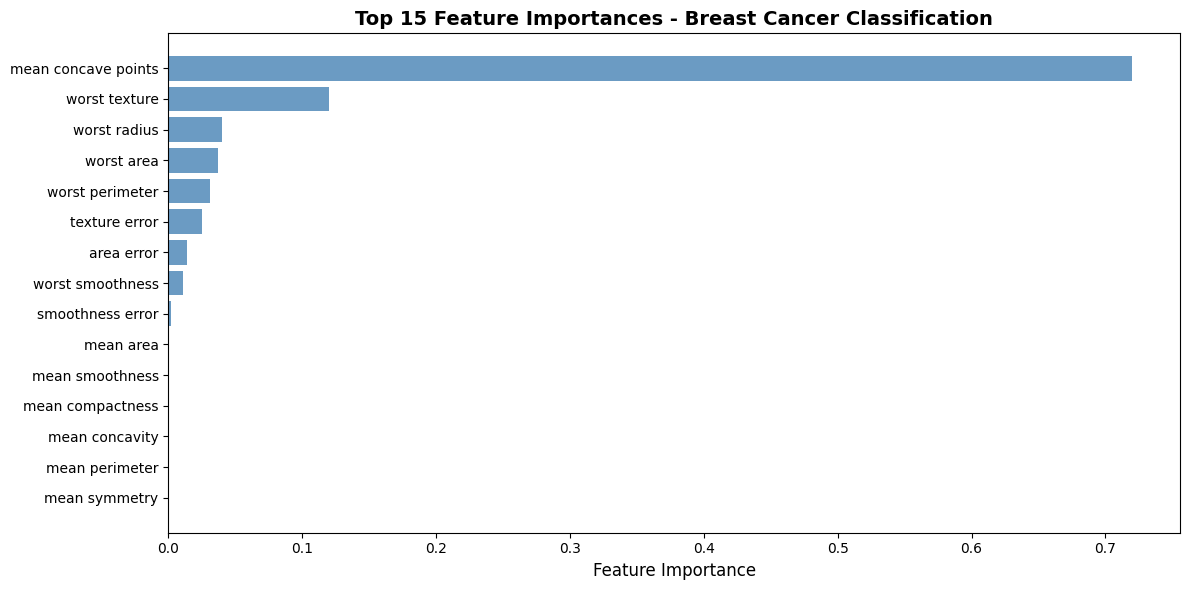

In [6]:
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

dt_best = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_best.fit(X_train_c, y_train_c)

importances = dt_best.feature_importances_
feature_names = cancer.feature_names

indices = np.argsort(importances)[::-1]

print("\nTop 10 Most Important Features:")
for i in range(10):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

plt.figure(figsize=(12, 6))
top_n = 15
plt.barh(range(top_n), importances[indices[:top_n]], color='steelblue', alpha=0.8)
plt.yticks(range(top_n), [feature_names[i] for i in indices[:top_n]])
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Top 15 Feature Importances - Breast Cancer Classification', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


CONFUSION MATRIX

Confusion Matrix:
[[ 59   4]
 [  4 104]]

True Negatives (Malignant correctly classified): 59
False Positives (Malignant predicted as Benign): 4
False Negatives (Benign predicted as Malignant): 4
True Positives (Benign correctly classified): 104


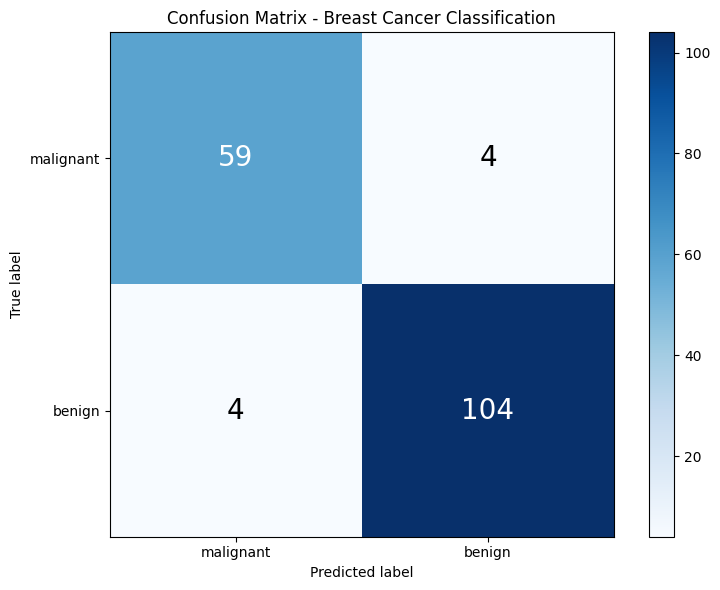

In [7]:
print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

dt_optimal = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_optimal.fit(X_train_c, y_train_c)
y_pred_c = dt_optimal.predict(X_test_c)

cm = confusion_matrix(y_test_c, y_pred_c)
print("\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives (Malignant correctly classified): {cm[0,0]}")
print(f"False Positives (Malignant predicted as Benign): {cm[0,1]}")
print(f"False Negatives (Benign predicted as Malignant): {cm[1,0]}")
print(f"True Positives (Benign correctly classified): {cm[1,1]}")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=cancer.target_names,
       yticklabels=cancer.target_names,
       ylabel='True label',
       xlabel='Predicted label',
       title='Confusion Matrix - Breast Cancer Classification')

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=20)
plt.tight_layout()
plt.show()


TREE STRUCTURE VISUALIZATION


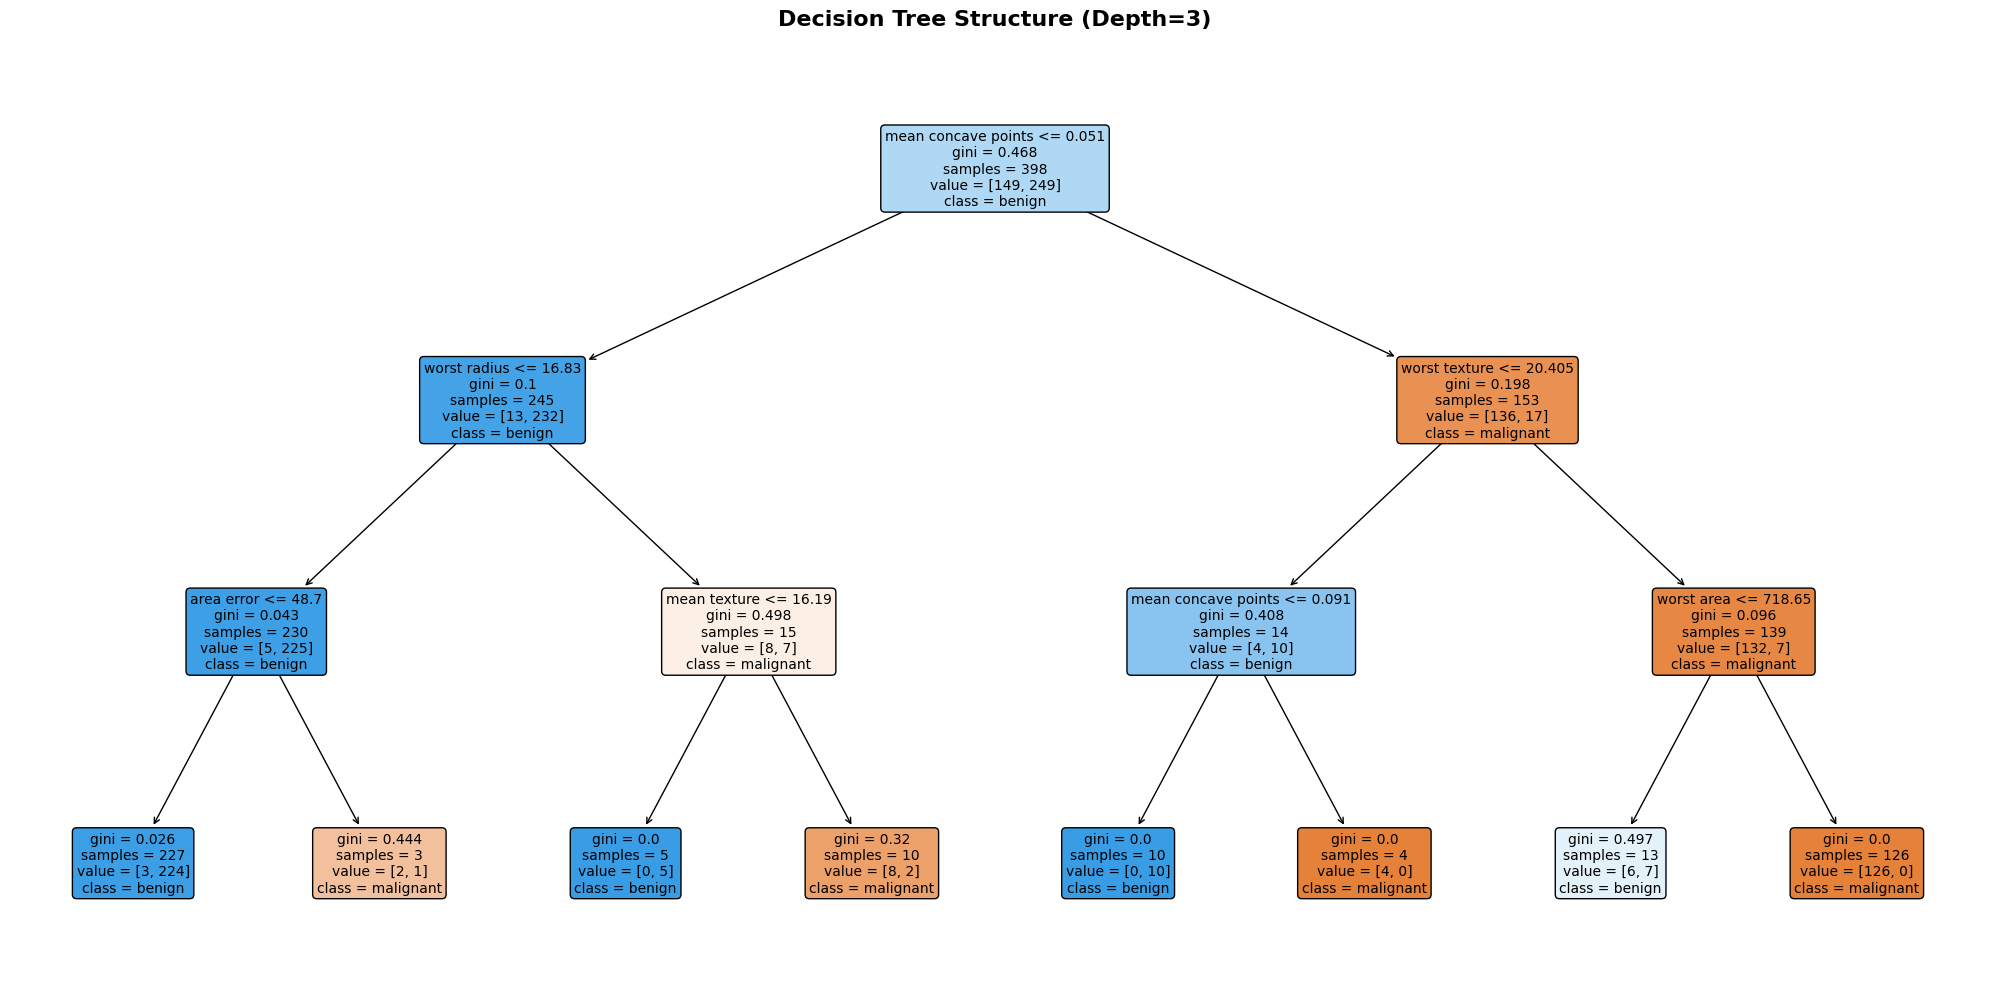


Tree Statistics:
  Max Depth: 3
  Number of Leaves: 8
  Test Accuracy: 0.9649


In [8]:
print("\n" + "=" * 60)
print("TREE STRUCTURE VISUALIZATION")
print("=" * 60)

dt_simple = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_simple.fit(X_train_c, y_train_c)

plt.figure(figsize=(20, 10))
plot_tree(dt_simple, 
          feature_names=cancer.feature_names,
          class_names=cancer.target_names,
          filled=True,
          fontsize=10,
          rounded=True)
plt.title('Decision Tree Structure (Depth=3)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f"\nTree Statistics:")
print(f"  Max Depth: {dt_simple.get_depth()}")
print(f"  Number of Leaves: {dt_simple.get_n_leaves()}")
print(f"  Test Accuracy: {accuracy_score(y_test_c, dt_simple.predict(X_test_c)):.4f}")


DECISION TREE CLASSIFIER: PRUNING ANALYSIS

Training pruned trees with different alpha values...

CLASSIFICATION: PRUNING RESULTS

Metric                    Unpruned Tree        Pruned Tree         
-----------------------------------------------------------------
Train Accuracy            1.0000               0.9824              
Test Accuracy             0.9415               0.9649              
Tree Depth                7                    4                   
Number of Leaves          16                   8                   
Complexity (alpha)        0.0                  0.008040            
-----------------------------------------------------------------

Overfitting Analysis:
  Unpruned train-test gap: 0.0585
  Pruned train-test gap:   0.0175
  Gap reduction: 70.08%


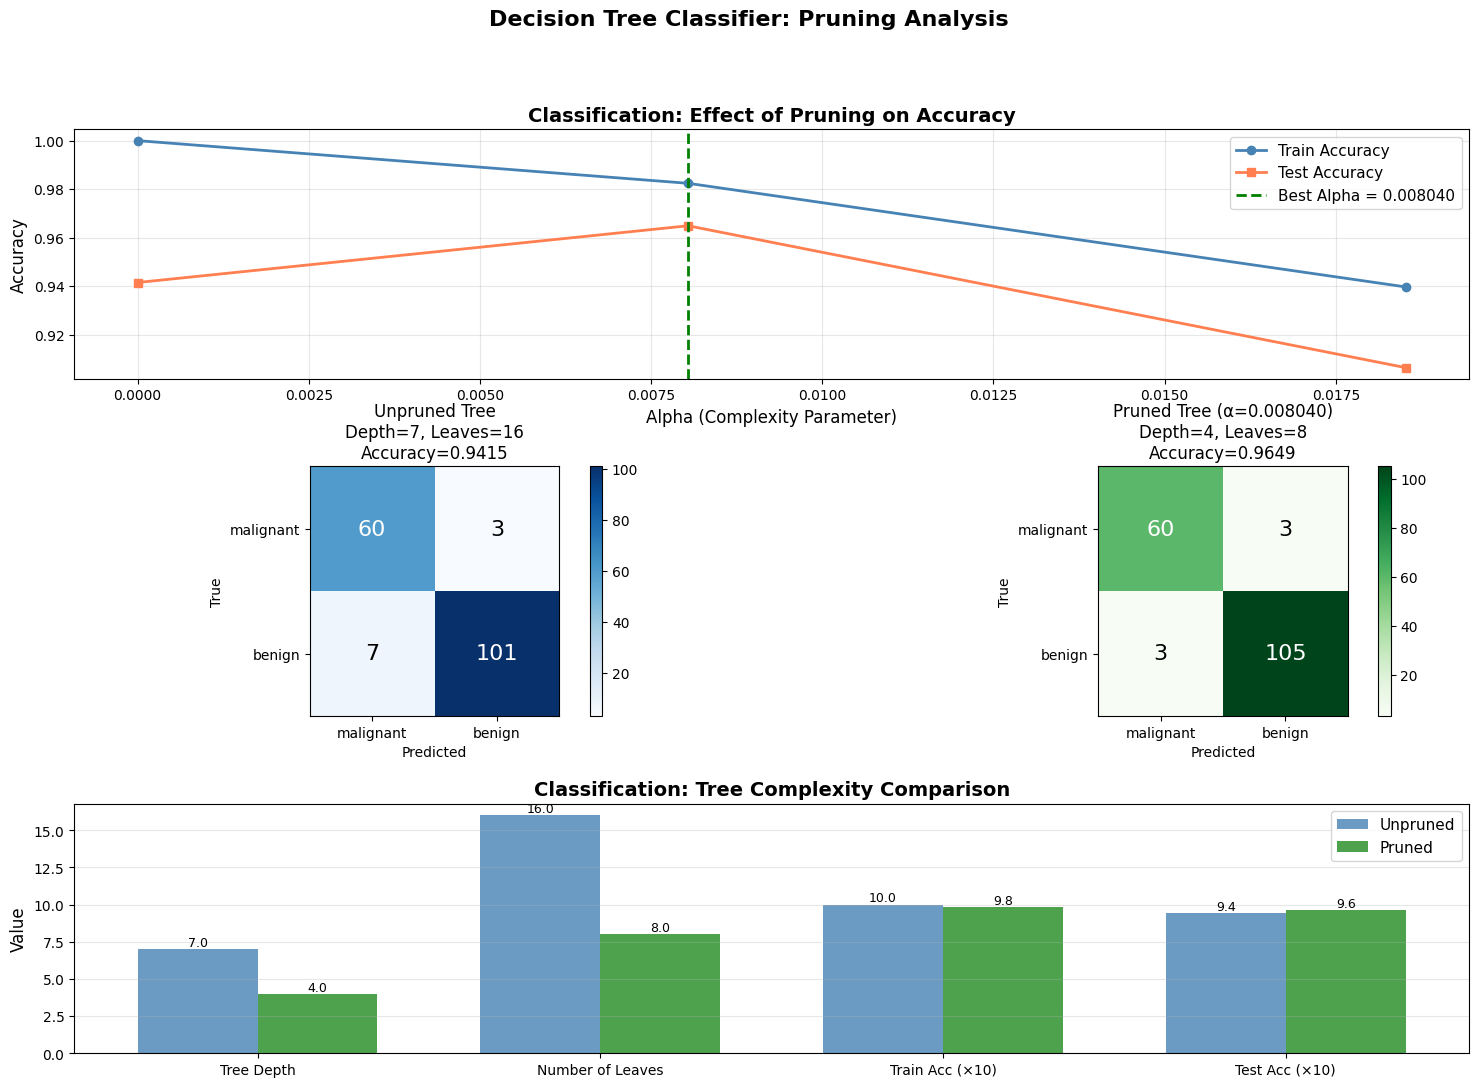

In [9]:
print("\n" + "="*60)
print("DECISION TREE CLASSIFIER: PRUNING ANALYSIS")
print("="*60)

# Train unpruned tree (full depth)
dt_unpruned_c = DecisionTreeClassifier(random_state=42)
dt_unpruned_c.fit(X_train_c, y_train_c)

# Get cost complexity pruning path
path = dt_unpruned_c.cost_complexity_pruning_path(X_train_c, y_train_c)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

# Remove the trivial tree (last alpha value)
ccp_alphas = ccp_alphas[:-1]

# Train trees with different alpha values
train_scores_c = []
test_scores_c = []
trees_info_c = []

print("\nTraining pruned trees with different alpha values...")
for alpha in ccp_alphas[::5]:  # Sample every 5th alpha for efficiency
    dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    dt_pruned.fit(X_train_c, y_train_c)
    
    train_scores_c.append(accuracy_score(y_train_c, dt_pruned.predict(X_train_c)))
    test_scores_c.append(accuracy_score(y_test_c, dt_pruned.predict(X_test_c)))
    trees_info_c.append({
        'alpha': alpha,
        'depth': dt_pruned.get_depth(),
        'leaves': dt_pruned.get_n_leaves()
    })

# Find best alpha
best_idx_c = np.argmax(test_scores_c)
best_alpha_c = ccp_alphas[::5][best_idx_c]

# Train final pruned tree with best alpha
dt_pruned_c = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha_c)
dt_pruned_c.fit(X_train_c, y_train_c)

# Compare unpruned vs pruned
unpruned_train_acc_c = accuracy_score(y_train_c, dt_unpruned_c.predict(X_train_c))
unpruned_test_acc_c = accuracy_score(y_test_c, dt_unpruned_c.predict(X_test_c))
pruned_train_acc_c = accuracy_score(y_train_c, dt_pruned_c.predict(X_train_c))
pruned_test_acc_c = accuracy_score(y_test_c, dt_pruned_c.predict(X_test_c))

print("\n" + "="*60)
print("CLASSIFICATION: PRUNING RESULTS")
print("="*60)
print(f"\n{'Metric':<25} {'Unpruned Tree':<20} {'Pruned Tree':<20}")
print("-" * 65)
print(f"{'Train Accuracy':<25} {unpruned_train_acc_c:<20.4f} {pruned_train_acc_c:<20.4f}")
print(f"{'Test Accuracy':<25} {unpruned_test_acc_c:<20.4f} {pruned_test_acc_c:<20.4f}")
print(f"{'Tree Depth':<25} {dt_unpruned_c.get_depth():<20} {dt_pruned_c.get_depth():<20}")
print(f"{'Number of Leaves':<25} {dt_unpruned_c.get_n_leaves():<20} {dt_pruned_c.get_n_leaves():<20}")
print(f"{'Complexity (alpha)':<25} {'0.0':<20} {best_alpha_c:<20.6f}")
print("-" * 65)

overfitting_reduction_c = unpruned_train_acc_c - unpruned_test_acc_c
pruned_gap_c = pruned_train_acc_c - pruned_test_acc_c

print(f"\nOverfitting Analysis:")
print(f"  Unpruned train-test gap: {overfitting_reduction_c:.4f}")
print(f"  Pruned train-test gap:   {pruned_gap_c:.4f}")
print(f"  Gap reduction: {((overfitting_reduction_c - pruned_gap_c) / overfitting_reduction_c * 100):.2f}%")

# Visualizations
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# Plot 1: Alpha vs Accuracy
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(ccp_alphas[::5], train_scores_c, 'o-', label='Train Accuracy', 
         linewidth=2, markersize=6, color='steelblue')
ax1.plot(ccp_alphas[::5], test_scores_c, 's-', label='Test Accuracy', 
         linewidth=2, markersize=6, color='coral')
ax1.axvline(x=best_alpha_c, color='green', linestyle='--', linewidth=2, 
            label=f'Best Alpha = {best_alpha_c:.6f}')
ax1.set_xlabel('Alpha (Complexity Parameter)', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Classification: Effect of Pruning on Accuracy', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Plot 2: Unpruned Confusion Matrix
ax2 = fig.add_subplot(gs[1, 0])
cm_unpruned_c = confusion_matrix(y_test_c, dt_unpruned_c.predict(X_test_c))
im2 = ax2.imshow(cm_unpruned_c, interpolation='nearest', cmap=plt.cm.Blues)
ax2.figure.colorbar(im2, ax=ax2)
ax2.set(xticks=np.arange(2), yticks=np.arange(2),
        xticklabels=cancer.target_names, yticklabels=cancer.target_names,
        ylabel='True', xlabel='Predicted',
        title=f'Unpruned Tree\nDepth={dt_unpruned_c.get_depth()}, Leaves={dt_unpruned_c.get_n_leaves()}\nAccuracy={unpruned_test_acc_c:.4f}')
for i in range(2):
    for j in range(2):
        ax2.text(j, i, format(cm_unpruned_c[i, j], 'd'),
                ha="center", va="center", fontsize=16,
                color="white" if cm_unpruned_c[i, j] > cm_unpruned_c.max()/2 else "black")

# Plot 3: Pruned Confusion Matrix
ax3 = fig.add_subplot(gs[1, 1])
cm_pruned_c = confusion_matrix(y_test_c, dt_pruned_c.predict(X_test_c))
im3 = ax3.imshow(cm_pruned_c, interpolation='nearest', cmap=plt.cm.Greens)
ax3.figure.colorbar(im3, ax=ax3)
ax3.set(xticks=np.arange(2), yticks=np.arange(2),
        xticklabels=cancer.target_names, yticklabels=cancer.target_names,
        ylabel='True', xlabel='Predicted',
        title=f'Pruned Tree (α={best_alpha_c:.6f})\nDepth={dt_pruned_c.get_depth()}, Leaves={dt_pruned_c.get_n_leaves()}\nAccuracy={pruned_test_acc_c:.4f}')
for i in range(2):
    for j in range(2):
        ax3.text(j, i, format(cm_pruned_c[i, j], 'd'),
                ha="center", va="center", fontsize=16,
                color="white" if cm_pruned_c[i, j] > cm_pruned_c.max()/2 else "black")

# Plot 4: Tree Complexity Comparison
ax4 = fig.add_subplot(gs[2, :])
categories = ['Tree Depth', 'Number of Leaves', 'Train Acc (×10)', 'Test Acc (×10)']
unpruned_values = [dt_unpruned_c.get_depth(), dt_unpruned_c.get_n_leaves(), 
                   unpruned_train_acc_c*10, unpruned_test_acc_c*10]
pruned_values = [dt_pruned_c.get_depth(), dt_pruned_c.get_n_leaves(), 
                pruned_train_acc_c*10, pruned_test_acc_c*10]

x = np.arange(len(categories))
width = 0.35

bars1 = ax4.bar(x - width/2, unpruned_values, width, label='Unpruned', 
                color='steelblue', alpha=0.8)
bars2 = ax4.bar(x + width/2, pruned_values, width, label='Pruned', 
                color='forestgreen', alpha=0.8)

ax4.set_ylabel('Value', fontsize=12)
ax4.set_title('Classification: Tree Complexity Comparison', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(categories)
ax4.legend(fontsize=11)
ax4.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Decision Tree Classifier: Pruning Analysis', fontsize=16, fontweight='bold')
plt.show()

In [10]:
print("\n\n" + "="*80)
print("DECISION TREE REGRESSOR")
print("="*80)

n_samples = 1000

temperature = np.random.uniform(15, 35, n_samples)
humidity = np.random.uniform(30, 90, n_samples)
wind_speed = np.random.uniform(0, 30, n_samples)
time_of_day = np.random.uniform(0, 24, n_samples)

energy_consumption = (
    50 +
    2.5 * temperature +
    -0.3 * humidity +
    0.8 * wind_speed +
    10 * np.sin(2 * np.pi * time_of_day / 24) +
    0.05 * temperature ** 2 +
    np.random.normal(0, 5, n_samples)  # Add noise
)

data_reg = pd.DataFrame({
    'Temperature': temperature,
    'Humidity': humidity,
    'Wind_Speed': wind_speed,
    'Time_of_Day': time_of_day,
    'Energy_Consumption': energy_consumption
})

print(f"\nDataset Shape: {data_reg.shape}")
print(f"Features: {list(data_reg.columns[:-1])}")
print(f"\nFirst few rows:")
print(data_reg.head())
print(f"\nStatistics:")
print(data_reg.describe())

X_reg = data_reg[['Temperature', 'Humidity', 'Wind_Speed', 'Time_of_Day']]
y_reg = data_reg['Energy_Consumption']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"\nTrain samples: {len(X_train_r)}")
print(f"Test samples: {len(X_test_r)}")



DECISION TREE REGRESSOR

Dataset Shape: (1000, 5)
Features: ['Temperature', 'Humidity', 'Wind_Speed', 'Time_of_Day']

First few rows:
   Temperature   Humidity  Wind_Speed  Time_of_Day  Energy_Consumption
0    28.765785  66.302325    5.274123    22.458236          133.257488
1    28.357175  39.326023    5.093755     1.695279          155.879278
2    33.494130  43.009480    2.786622     9.003744          185.304311
3    24.641718  79.791196   27.186162     3.015122          143.284650
4    31.747477  74.135615    3.229899     1.744096          162.401968

Statistics:
       Temperature     Humidity   Wind_Speed  Time_of_Day  Energy_Consumption
count  1000.000000  1000.000000  1000.000000  1000.000000         1000.000000
mean     25.143005    60.924451    15.512229    11.935890          140.542544
std       5.785825    16.941887     8.746321     6.818746           31.199090
min      15.004787    30.057963     0.065374     0.018219           66.358475
25%      20.059684    46.736393    

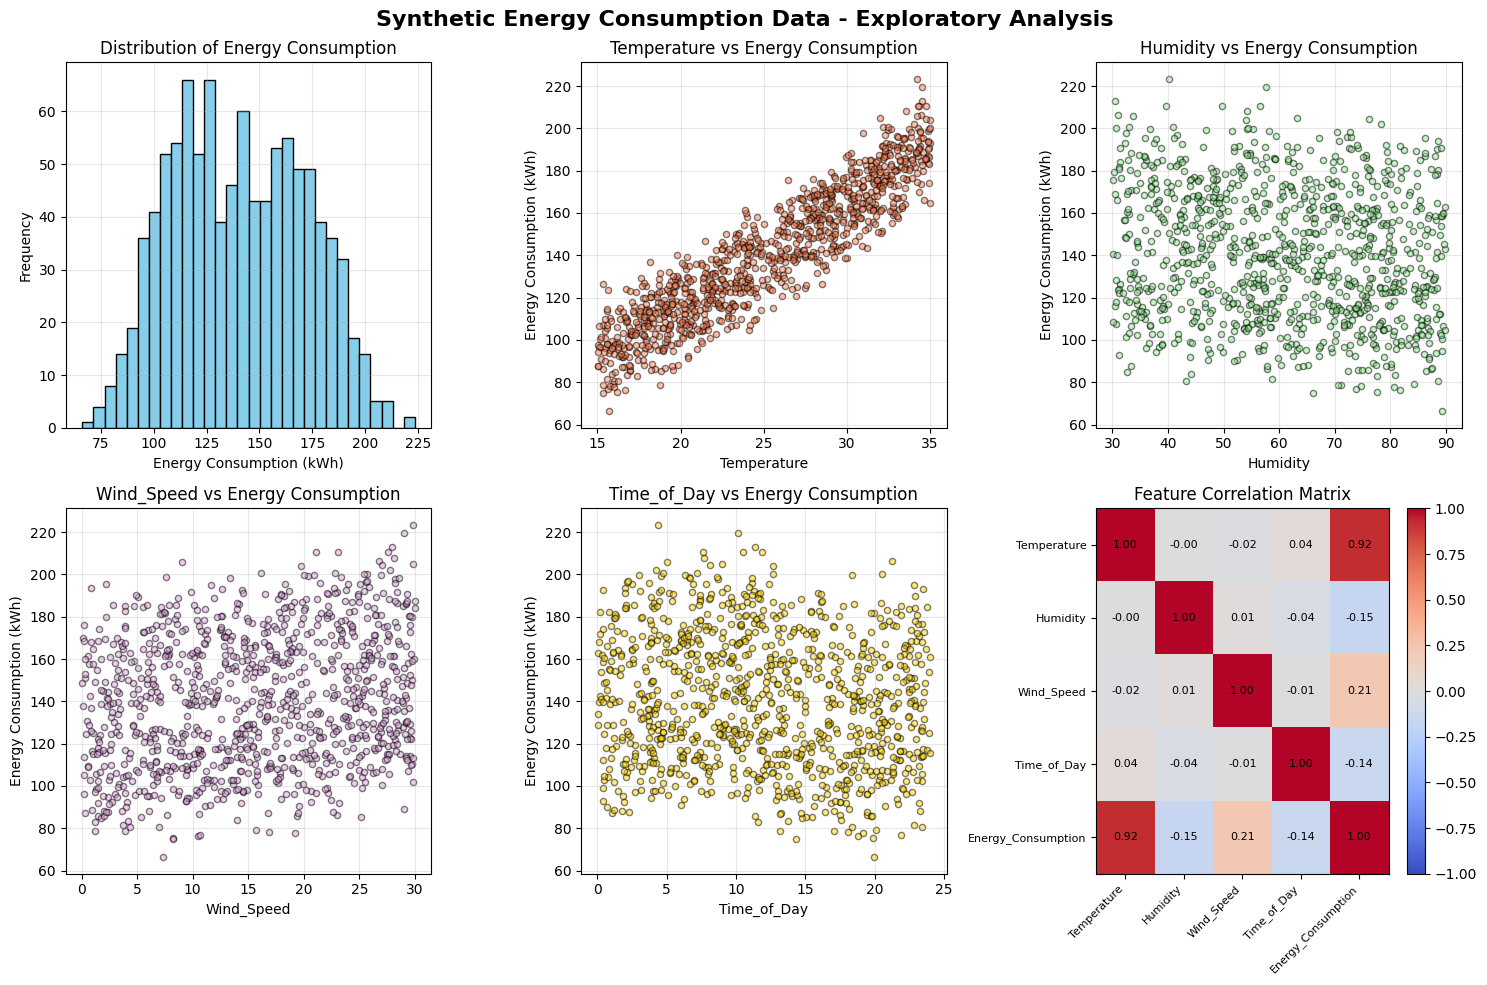

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Synthetic Energy Consumption Data - Exploratory Analysis', 
             fontsize=16, fontweight='bold')

axes[0, 0].hist(data_reg['Energy_Consumption'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Energy Consumption (kWh)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Energy Consumption')
axes[0, 0].grid(alpha=0.3)

features_r = ['Temperature', 'Humidity', 'Wind_Speed', 'Time_of_Day']
colors = ['coral', 'lightgreen', 'plum', 'gold']

for idx, (feature, color) in enumerate(zip(features_r, colors)):
    row = (idx + 1) // 3
    col = (idx + 1) % 3
    axes[row, col].scatter(data_reg[feature], data_reg['Energy_Consumption'], 
                          alpha=0.5, c=color, edgecolors='black', s=20)
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Energy Consumption (kWh)')
    axes[row, col].set_title(f'{feature} vs Energy Consumption')
    axes[row, col].grid(alpha=0.3)

corr_matrix = data_reg.corr()
im = axes[1, 2].imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
axes[1, 2].set_xticks(range(len(corr_matrix)))
axes[1, 2].set_yticks(range(len(corr_matrix)))
axes[1, 2].set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=8)
axes[1, 2].set_yticklabels(corr_matrix.columns, fontsize=8)
axes[1, 2].set_title('Feature Correlation Matrix')

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        axes[1, 2].text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=8)

plt.colorbar(im, ax=axes[1, 2])
plt.tight_layout()
plt.show()

In [12]:
print("\n" + "="*60)
print("COMPARING DECISION TREE DEPTHS")
print("="*60)

depths = [1, 3, 5, 10, 20, None]
results_r = []

for depth in depths:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    
    start_time = time.time()
    dt.fit(X_train_r, y_train_r)
    train_time = (time.time() - start_time) * 1000
    
    train_pred = dt.predict(X_train_r)
    test_pred = dt.predict(X_test_r)
    
    train_rmse = np.sqrt(mean_squared_error(y_train_r, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_r, test_pred))
    train_r2 = r2_score(y_train_r, train_pred)
    test_r2 = r2_score(y_test_r, test_pred)
    
    results_r.append({
        'depth': depth if depth else 'None',
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'time': train_time
    })
    
    print(f"\nMax Depth: {depth if depth else 'Unlimited'}")
    print(f"  Train RMSE: {train_rmse:.4f}")
    print(f"  Test RMSE:  {test_rmse:.4f}")
    print(f"  Train R²:   {train_r2:.4f}")
    print(f"  Test R²:    {test_r2:.4f}")
    print(f"  Training Time: {train_time:.2f} ms")
    print(f"  Tree Depth:    {dt.get_depth()}")
    print(f"  Num Leaves:    {dt.get_n_leaves()}")


COMPARING DECISION TREE DEPTHS

Max Depth: 1
  Train RMSE: 18.0091
  Test RMSE:  18.9617
  Train R²:   0.6462
  Test R²:    0.6990
  Training Time: 17.86 ms
  Tree Depth:    1
  Num Leaves:    2

Max Depth: 3
  Train RMSE: 11.5554
  Test RMSE:  13.3003
  Train R²:   0.8543
  Test R²:    0.8519
  Training Time: 2.62 ms
  Tree Depth:    3
  Num Leaves:    8

Max Depth: 5
  Train RMSE: 7.8061
  Test RMSE:  10.2527
  Train R²:   0.9335
  Test R²:    0.9120
  Training Time: 21.52 ms
  Tree Depth:    5
  Num Leaves:    32

Max Depth: 10
  Train RMSE: 1.5916
  Test RMSE:  10.0199
  Train R²:   0.9972
  Test R²:    0.9159
  Training Time: 4.20 ms
  Tree Depth:    10
  Num Leaves:    507

Max Depth: 20
  Train RMSE: 0.0000
  Test RMSE:  9.6101
  Train R²:   1.0000
  Test R²:    0.9227
  Training Time: 3.42 ms
  Tree Depth:    17
  Num Leaves:    800

Max Depth: Unlimited
  Train RMSE: 0.0000
  Test RMSE:  9.6101
  Train R²:   1.0000
  Test R²:    0.9227
  Training Time: 4.04 ms
  Tree Depth:  


OVERFITTING ANALYSIS


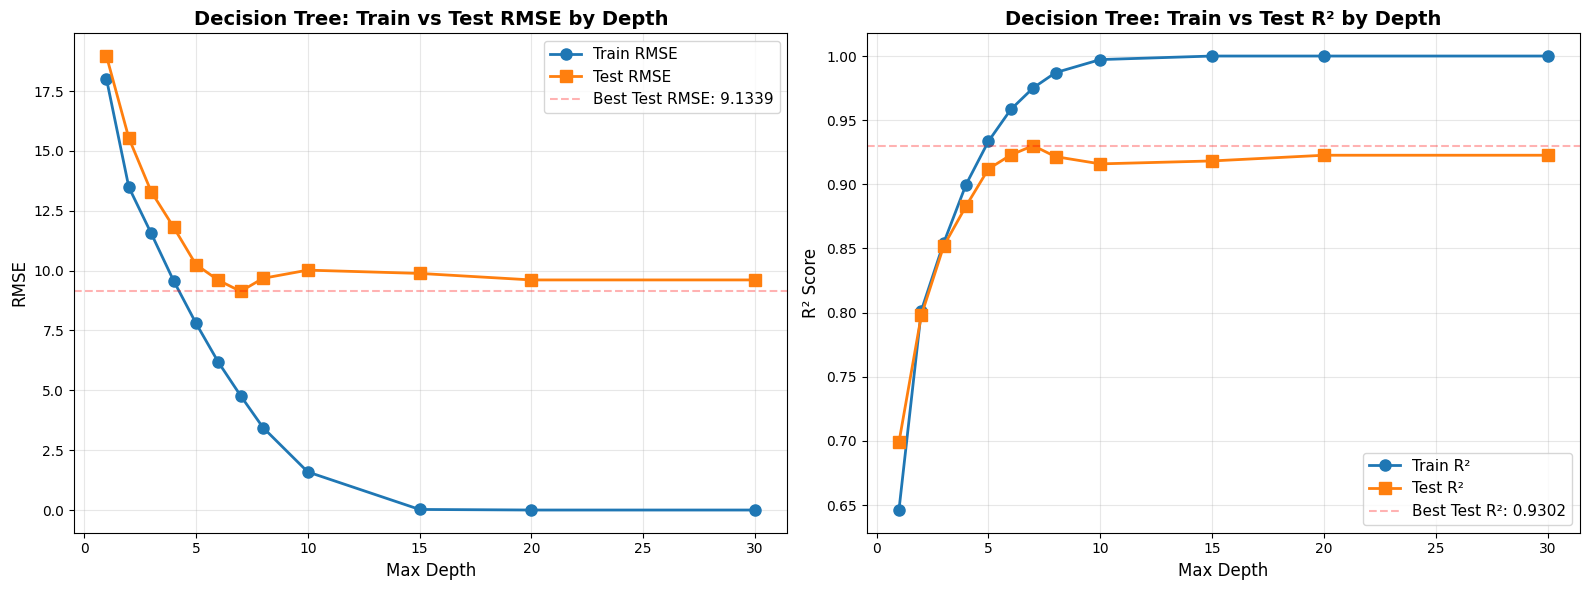


Best Test R²: 0.9302 at depth 7
Best Test RMSE: 9.1339 at depth 7
Overfitting becomes significant after depth 7


In [13]:
print("\n" + "="*60)
print("OVERFITTING ANALYSIS")
print("="*60)

depth_values = [1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 20, 30]
train_rmses = []
test_rmses = []
train_r2s = []
test_r2s = []

for depth in depth_values:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train_r, y_train_r)
    
    train_pred = dt.predict(X_train_r)
    test_pred = dt.predict(X_test_r)
    
    train_rmses.append(np.sqrt(mean_squared_error(y_train_r, train_pred)))
    test_rmses.append(np.sqrt(mean_squared_error(y_test_r, test_pred)))
    train_r2s.append(r2_score(y_train_r, train_pred))
    test_r2s.append(r2_score(y_test_r, test_pred))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(depth_values, train_rmses, 'o-', label='Train RMSE', linewidth=2, markersize=8)
ax1.plot(depth_values, test_rmses, 's-', label='Test RMSE', linewidth=2, markersize=8)
ax1.axhline(y=min(test_rmses), color='r', linestyle='--', alpha=0.3, 
            label=f'Best Test RMSE: {min(test_rmses):.4f}')
ax1.set_xlabel('Max Depth', fontsize=12)
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_title('Decision Tree: Train vs Test RMSE by Depth', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(depth_values, train_r2s, 'o-', label='Train R²', linewidth=2, markersize=8)
ax2.plot(depth_values, test_r2s, 's-', label='Test R²', linewidth=2, markersize=8)
ax2.axhline(y=max(test_r2s), color='r', linestyle='--', alpha=0.3, 
            label=f'Best Test R²: {max(test_r2s):.4f}')
ax2.set_xlabel('Max Depth', fontsize=12)
ax2.set_ylabel('R² Score', fontsize=12)
ax2.set_title('Decision Tree: Train vs Test R² by Depth', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_depth_idx = np.argmax(test_r2s)
print(f"\nBest Test R²: {max(test_r2s):.4f} at depth {depth_values[best_depth_idx]}")
print(f"Best Test RMSE: {min(test_rmses):.4f} at depth {depth_values[np.argmin(test_rmses)]}")
print(f"Overfitting becomes significant after depth {depth_values[best_depth_idx]}")


FEATURE IMPORTANCE ANALYSIS

Feature Importances:
1. Temperature: 0.9009
2. Wind_Speed: 0.0526
3. Time_of_Day: 0.0404
4. Humidity: 0.0061


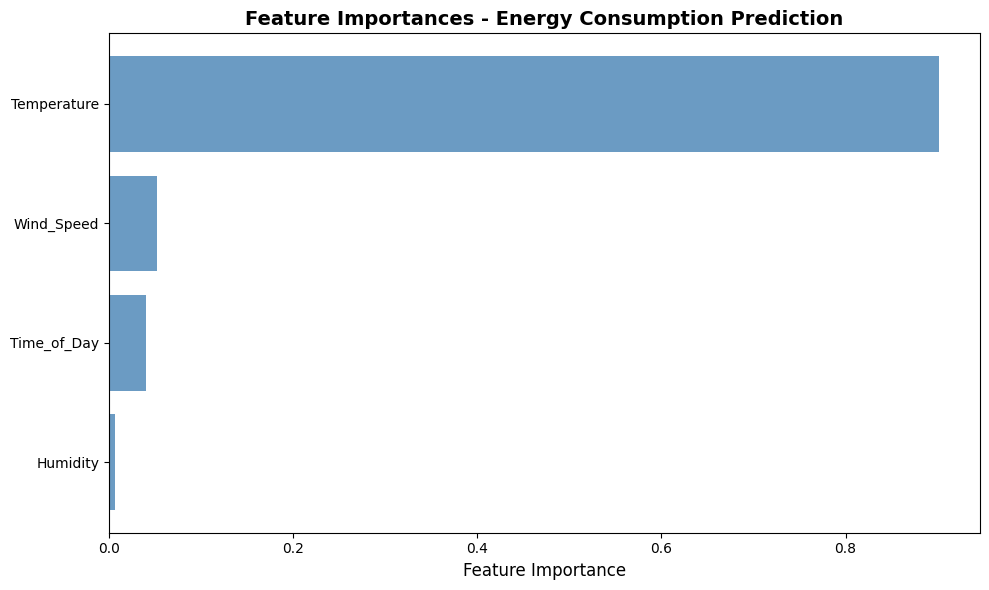

In [14]:
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

dt_best_r = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_best_r.fit(X_train_r, y_train_r)

importances_r = dt_best_r.feature_importances_
feature_names_r = ['Temperature', 'Humidity', 'Wind_Speed', 'Time_of_Day']
indices_r = np.argsort(importances_r)[::-1]

print("\nFeature Importances:")
for i in range(len(feature_names_r)):
    print(f"{i+1}. {feature_names_r[indices_r[i]]}: {importances_r[indices_r[i]]:.4f}")

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_names_r)), importances_r[indices_r], color='steelblue', alpha=0.8)
plt.yticks(range(len(feature_names_r)), [feature_names_r[i] for i in indices_r])
plt.xlabel('Feature Importance', fontsize=12)
plt.title('Feature Importances - Energy Consumption Prediction', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


PREDICTION ANALYSIS

Optimal Model Performance (depth=5):
  Test RMSE: 10.2527
  Test MAE:  8.0654
  Test R²:   0.9120


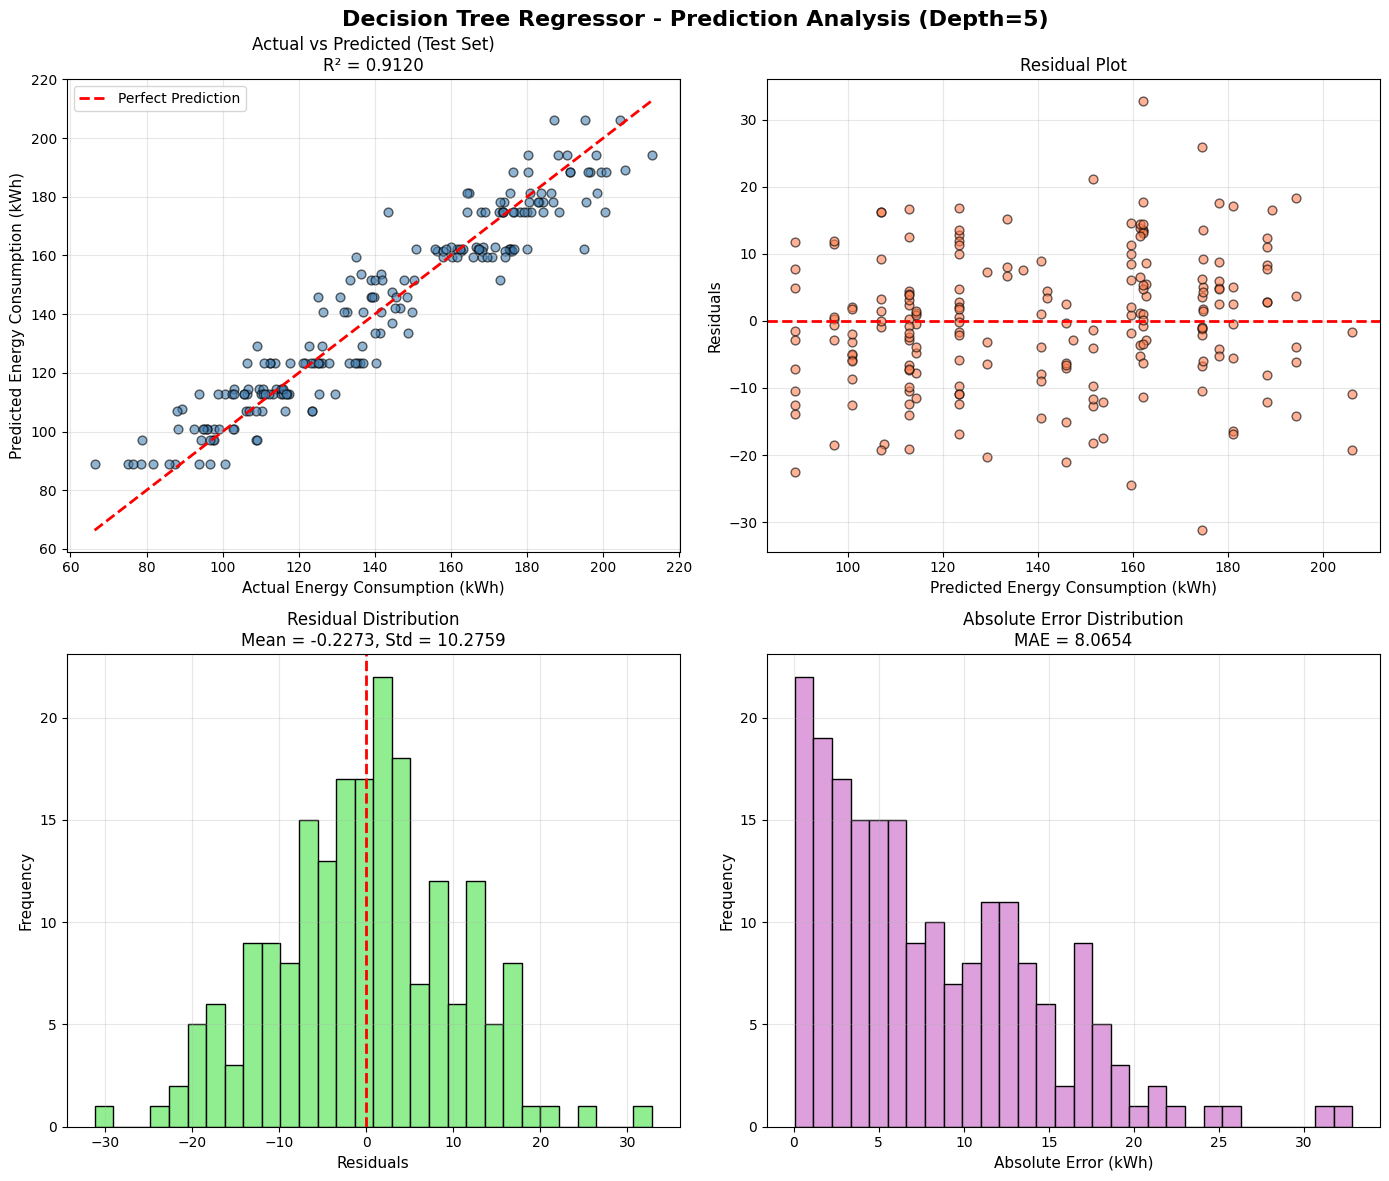

In [15]:
print("\n" + "="*60)
print("PREDICTION ANALYSIS")
print("="*60)

y_pred_r = dt_best_r.predict(X_test_r)
residuals_r = y_test_r - y_pred_r

test_rmse_r = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
test_mae_r = mean_absolute_error(y_test_r, y_pred_r)
test_r2_r = r2_score(y_test_r, y_pred_r)

print(f"\nOptimal Model Performance (depth=5):")
print(f"  Test RMSE: {test_rmse_r:.4f}")
print(f"  Test MAE:  {test_mae_r:.4f}")
print(f"  Test R²:   {test_r2_r:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Decision Tree Regressor - Prediction Analysis (Depth=5)', 
             fontsize=16, fontweight='bold')

axes[0, 0].scatter(y_test_r, y_pred_r, alpha=0.6, c='steelblue', edgecolors='black', s=40)
axes[0, 0].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Energy Consumption (kWh)', fontsize=11)
axes[0, 0].set_ylabel('Predicted Energy Consumption (kWh)', fontsize=11)
axes[0, 0].set_title(f'Actual vs Predicted (Test Set)\nR² = {test_r2_r:.4f}', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].scatter(y_pred_r, residuals_r, alpha=0.6, c='coral', edgecolors='black', s=40)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Energy Consumption (kWh)', fontsize=11)
axes[0, 1].set_ylabel('Residuals', fontsize=11)
axes[0, 1].set_title('Residual Plot', fontsize=12)
axes[0, 1].grid(alpha=0.3)

axes[1, 0].hist(residuals_r, bins=30, color='lightgreen', edgecolor='black')
axes[1, 0].set_xlabel('Residuals', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title(f'Residual Distribution\nMean = {residuals_r.mean():.4f}, Std = {residuals_r.std():.4f}', 
                     fontsize=12)
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].grid(alpha=0.3)

errors_r = np.abs(residuals_r)
axes[1, 1].hist(errors_r, bins=30, color='plum', edgecolor='black')
axes[1, 1].set_xlabel('Absolute Error (kWh)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title(f'Absolute Error Distribution\nMAE = {test_mae_r:.4f}', fontsize=12)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


TREE STRUCTURE VISUALIZATION


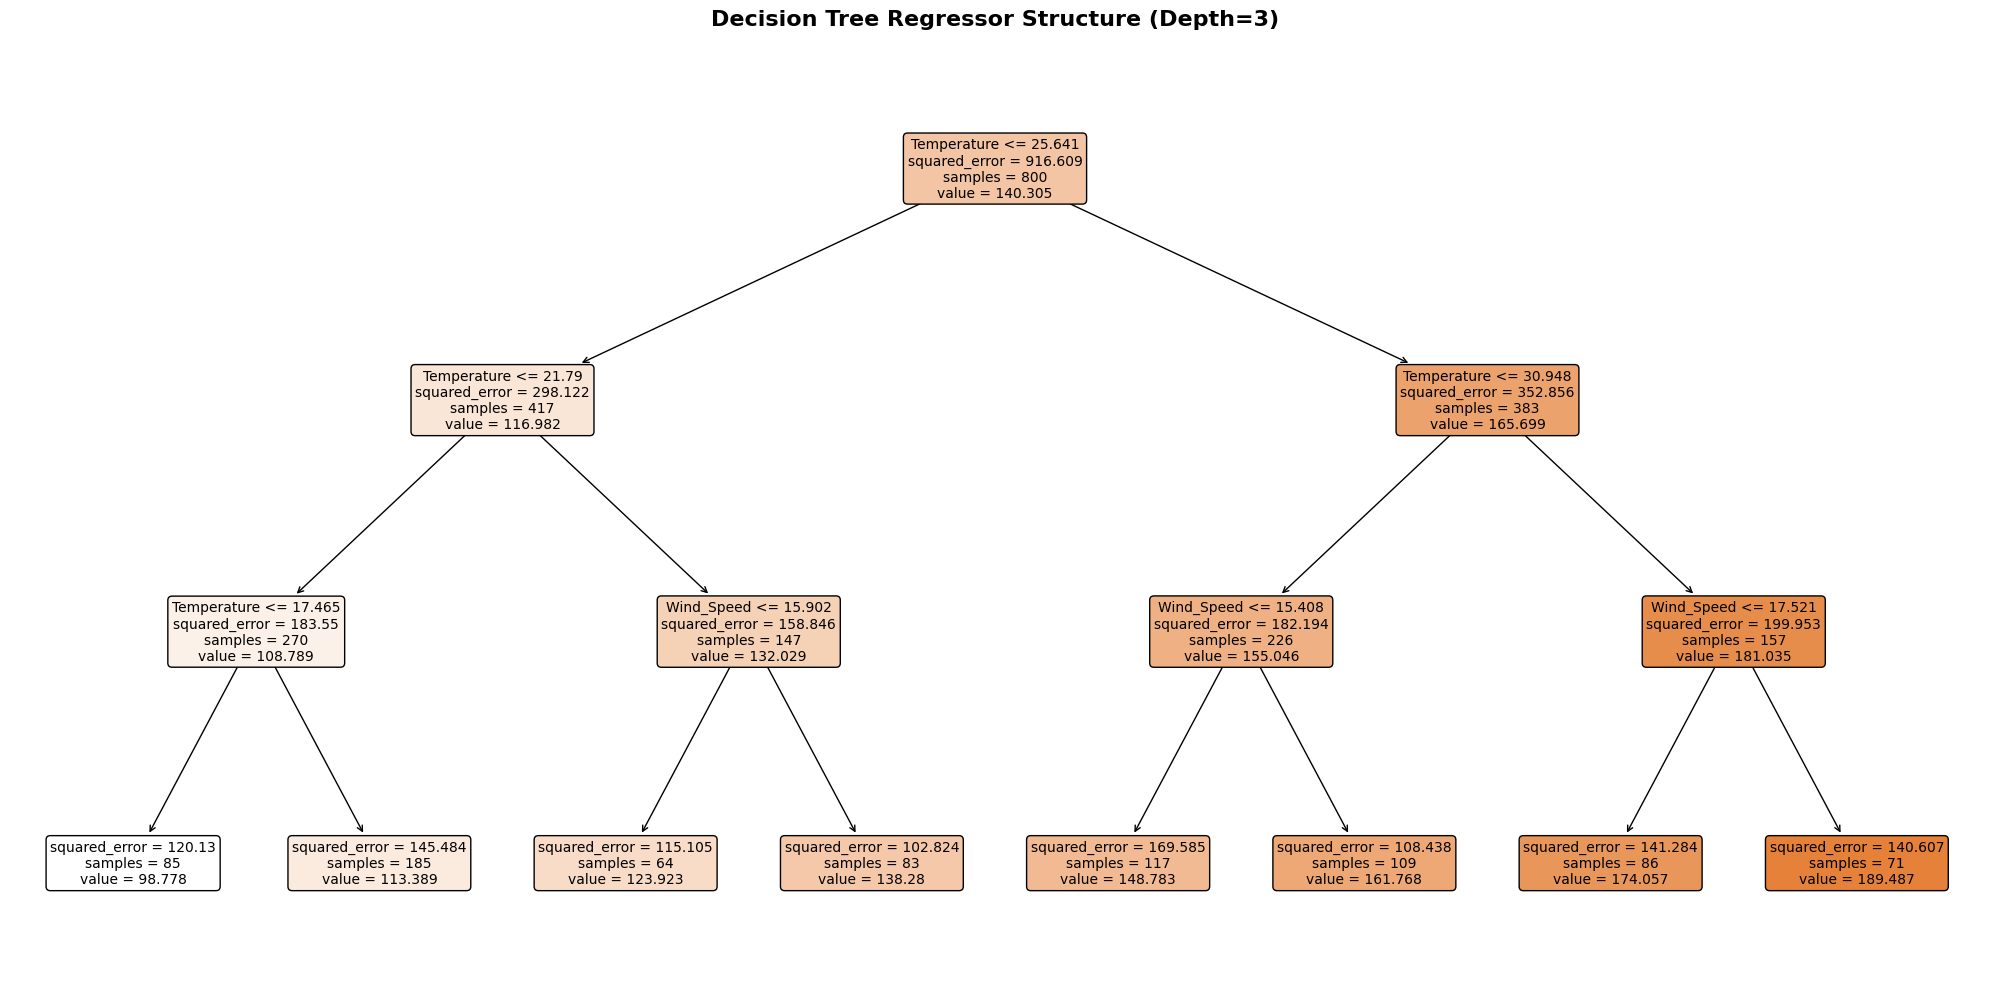


Tree Statistics:
  Max Depth: 3
  Number of Leaves: 8
  Test R²: 0.8519


In [16]:
print("\n" + "="*60)
print("TREE STRUCTURE VISUALIZATION")
print("="*60)

dt_simple_r = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_simple_r.fit(X_train_r, y_train_r)

plt.figure(figsize=(20, 10))
plot_tree(dt_simple_r, 
          feature_names=feature_names_r,
          filled=True,
          fontsize=10,
          rounded=True)
plt.title('Decision Tree Regressor Structure (Depth=3)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f"\nTree Statistics:")
print(f"  Max Depth: {dt_simple_r.get_depth()}")
print(f"  Number of Leaves: {dt_simple_r.get_n_leaves()}")
print(f"  Test R²: {r2_score(y_test_r, dt_simple_r.predict(X_test_r)):.4f}")



DECISION TREE REGRESSOR: PRUNING ANALYSIS

Training pruned trees with different alpha values...

REGRESSION: PRUNING RESULTS

Metric                    Unpruned Tree        Pruned Tree         
-----------------------------------------------------------------
Train R²                  1.0000               0.9751              
Test R²                   0.9227               0.9326              
Train RMSE                0.0000               4.7772              
Test RMSE                 9.6101               8.9705              
Tree Depth                17                   9                   
Number of Leaves          800                  103                 
Complexity (alpha)        0.0                  0.220121            
-----------------------------------------------------------------

Overfitting Analysis:
  Unpruned R² train-test gap: 0.0773
  Pruned R² train-test gap:   0.0425
  RMSE improvement: 6.65%


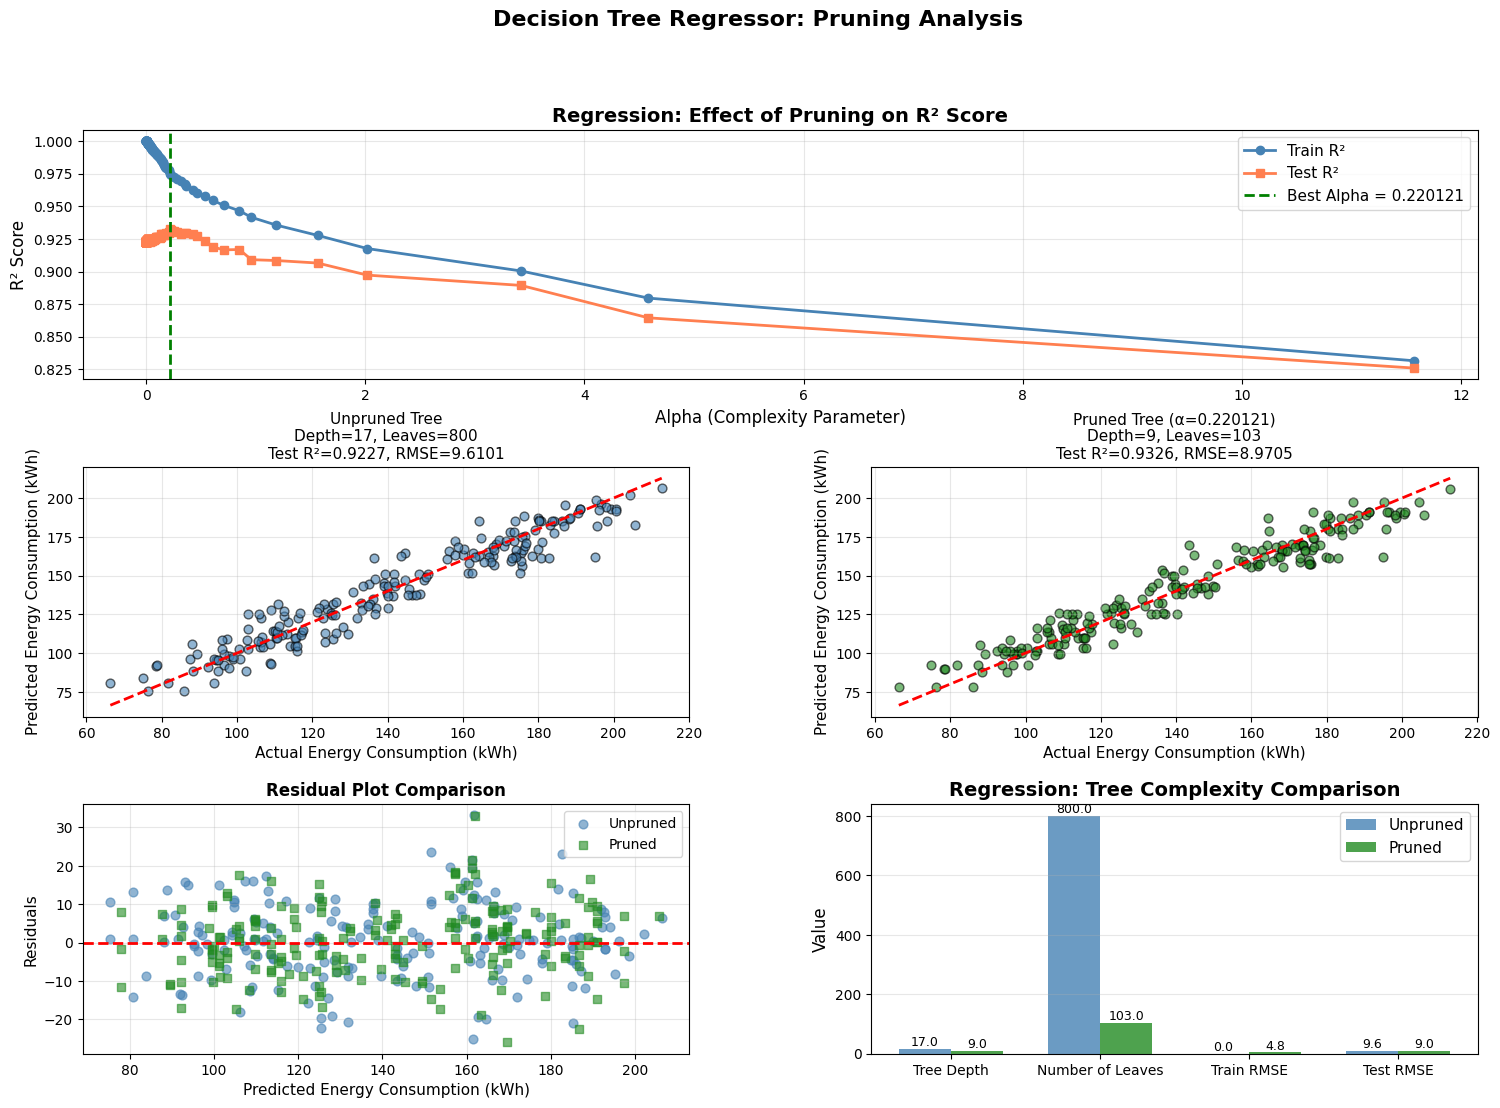

In [17]:
print("\n\n" + "="*60)
print("DECISION TREE REGRESSOR: PRUNING ANALYSIS")
print("="*60)

# Train unpruned tree (full depth)
dt_unpruned_r = DecisionTreeRegressor(random_state=42)
dt_unpruned_r.fit(X_train_r, y_train_r)

# Get cost complexity pruning path
path_r = dt_unpruned_r.cost_complexity_pruning_path(X_train_r, y_train_r)
ccp_alphas_r = path_r.ccp_alphas
ccp_alphas_r = ccp_alphas_r[:-1]

# Train trees with different alpha values
train_scores_r = []
test_scores_r = []
trees_info_r = []

print("\nTraining pruned trees with different alpha values...")
for alpha in ccp_alphas_r[::5]:  # Sample every 5th alpha for efficiency
    dt_pruned = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    dt_pruned.fit(X_train_r, y_train_r)
    
    train_scores_r.append(r2_score(y_train_r, dt_pruned.predict(X_train_r)))
    test_scores_r.append(r2_score(y_test_r, dt_pruned.predict(X_test_r)))
    trees_info_r.append({
        'alpha': alpha,
        'depth': dt_pruned.get_depth(),
        'leaves': dt_pruned.get_n_leaves()
    })

# Find best alpha
best_idx_r = np.argmax(test_scores_r)
best_alpha_r = ccp_alphas_r[::5][best_idx_r]

# Train final pruned tree with best alpha
dt_pruned_r = DecisionTreeRegressor(random_state=42, ccp_alpha=best_alpha_r)
dt_pruned_r.fit(X_train_r, y_train_r)

# Compare unpruned vs pruned
unpruned_train_r2_r = r2_score(y_train_r, dt_unpruned_r.predict(X_train_r))
unpruned_test_r2_r = r2_score(y_test_r, dt_unpruned_r.predict(X_test_r))
unpruned_train_rmse_r = np.sqrt(mean_squared_error(y_train_r, dt_unpruned_r.predict(X_train_r)))
unpruned_test_rmse_r = np.sqrt(mean_squared_error(y_test_r, dt_unpruned_r.predict(X_test_r)))

pruned_train_r2_r = r2_score(y_train_r, dt_pruned_r.predict(X_train_r))
pruned_test_r2_r = r2_score(y_test_r, dt_pruned_r.predict(X_test_r))
pruned_train_rmse_r = np.sqrt(mean_squared_error(y_train_r, dt_pruned_r.predict(X_train_r)))
pruned_test_rmse_r = np.sqrt(mean_squared_error(y_test_r, dt_pruned_r.predict(X_test_r)))

print("\n" + "="*60)
print("REGRESSION: PRUNING RESULTS")
print("="*60)
print(f"\n{'Metric':<25} {'Unpruned Tree':<20} {'Pruned Tree':<20}")
print("-" * 65)
print(f"{'Train R²':<25} {unpruned_train_r2_r:<20.4f} {pruned_train_r2_r:<20.4f}")
print(f"{'Test R²':<25} {unpruned_test_r2_r:<20.4f} {pruned_test_r2_r:<20.4f}")
print(f"{'Train RMSE':<25} {unpruned_train_rmse_r:<20.4f} {pruned_train_rmse_r:<20.4f}")
print(f"{'Test RMSE':<25} {unpruned_test_rmse_r:<20.4f} {pruned_test_rmse_r:<20.4f}")
print(f"{'Tree Depth':<25} {dt_unpruned_r.get_depth():<20} {dt_pruned_r.get_depth():<20}")
print(f"{'Number of Leaves':<25} {dt_unpruned_r.get_n_leaves():<20} {dt_pruned_r.get_n_leaves():<20}")
print(f"{'Complexity (alpha)':<25} {'0.0':<20} {best_alpha_r:<20.6f}")
print("-" * 65)

overfitting_r2_gap = unpruned_train_r2_r - unpruned_test_r2_r
pruned_r2_gap = pruned_train_r2_r - pruned_test_r2_r

print(f"\nOverfitting Analysis:")
print(f"  Unpruned R² train-test gap: {overfitting_r2_gap:.4f}")
print(f"  Pruned R² train-test gap:   {pruned_r2_gap:.4f}")
print(f"  RMSE improvement: {((unpruned_test_rmse_r - pruned_test_rmse_r) / unpruned_test_rmse_r * 100):.2f}%")

# Visualizations
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# Plot 1: Alpha vs R² Score
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(ccp_alphas_r[::5], train_scores_r, 'o-', label='Train R²', 
         linewidth=2, markersize=6, color='steelblue')
ax1.plot(ccp_alphas_r[::5], test_scores_r, 's-', label='Test R²', 
         linewidth=2, markersize=6, color='coral')
ax1.axvline(x=best_alpha_r, color='green', linestyle='--', linewidth=2, 
            label=f'Best Alpha = {best_alpha_r:.6f}')
ax1.set_xlabel('Alpha (Complexity Parameter)', fontsize=12)
ax1.set_ylabel('R² Score', fontsize=12)
ax1.set_title('Regression: Effect of Pruning on R² Score', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Plot 2: Unpruned Predictions
ax2 = fig.add_subplot(gs[1, 0])
y_pred_unpruned_r = dt_unpruned_r.predict(X_test_r)
ax2.scatter(y_test_r, y_pred_unpruned_r, alpha=0.6, c='steelblue', 
           edgecolors='black', s=40)
ax2.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 
         'r--', lw=2)
ax2.set_xlabel('Actual Energy Consumption (kWh)', fontsize=11)
ax2.set_ylabel('Predicted Energy Consumption (kWh)', fontsize=11)
ax2.set_title(f'Unpruned Tree\nDepth={dt_unpruned_r.get_depth()}, Leaves={dt_unpruned_r.get_n_leaves()}\nTest R²={unpruned_test_r2_r:.4f}, RMSE={unpruned_test_rmse_r:.4f}', 
             fontsize=11)
ax2.grid(alpha=0.3)

# Plot 3: Pruned Predictions
ax3 = fig.add_subplot(gs[1, 1])
y_pred_pruned_r = dt_pruned_r.predict(X_test_r)
ax3.scatter(y_test_r, y_pred_pruned_r, alpha=0.6, c='forestgreen', 
           edgecolors='black', s=40)
ax3.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 
         'r--', lw=2)
ax3.set_xlabel('Actual Energy Consumption (kWh)', fontsize=11)
ax3.set_ylabel('Predicted Energy Consumption (kWh)', fontsize=11)
ax3.set_title(f'Pruned Tree (α={best_alpha_r:.6f})\nDepth={dt_pruned_r.get_depth()}, Leaves={dt_pruned_r.get_n_leaves()}\nTest R²={pruned_test_r2_r:.4f}, RMSE={pruned_test_rmse_r:.4f}', 
             fontsize=11)
ax3.grid(alpha=0.3)

# Plot 4: Residual Comparison
ax4 = fig.add_subplot(gs[2, 0])
residuals_unpruned = y_test_r - y_pred_unpruned_r
residuals_pruned = y_test_r - y_pred_pruned_r
ax4.scatter(y_pred_unpruned_r, residuals_unpruned, alpha=0.6, 
           c='steelblue', label='Unpruned', s=40)
ax4.scatter(y_pred_pruned_r, residuals_pruned, alpha=0.6, 
           c='forestgreen', label='Pruned', s=40, marker='s')
ax4.axhline(y=0, color='r', linestyle='--', lw=2)
ax4.set_xlabel('Predicted Energy Consumption (kWh)', fontsize=11)
ax4.set_ylabel('Residuals', fontsize=11)
ax4.set_title('Residual Plot Comparison', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(alpha=0.3)

# Plot 5: Tree Complexity Comparison
ax5 = fig.add_subplot(gs[2, 1])
categories = ['Tree Depth', 'Number of Leaves', 'Train RMSE', 'Test RMSE']
unpruned_values = [dt_unpruned_r.get_depth(), dt_unpruned_r.get_n_leaves(), 
                   unpruned_train_rmse_r, unpruned_test_rmse_r]
pruned_values = [dt_pruned_r.get_depth(), dt_pruned_r.get_n_leaves(), 
                pruned_train_rmse_r, pruned_test_rmse_r]

x = np.arange(len(categories))
width = 0.35

bars1 = ax5.bar(x - width/2, unpruned_values, width, label='Unpruned', 
                color='steelblue', alpha=0.8)
bars2 = ax5.bar(x + width/2, pruned_values, width, label='Pruned', 
                color='forestgreen', alpha=0.8)

ax5.set_ylabel('Value', fontsize=12)
ax5.set_title('Regression: Tree Complexity Comparison', fontsize=14, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(categories, fontsize=10)
ax5.legend(fontsize=11)
ax5.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Decision Tree Regressor: Pruning Analysis', fontsize=16, fontweight='bold')
plt.show()


DECISION TREE STEP FUNCTIONS - HOW PREDICTIONS CHANGE


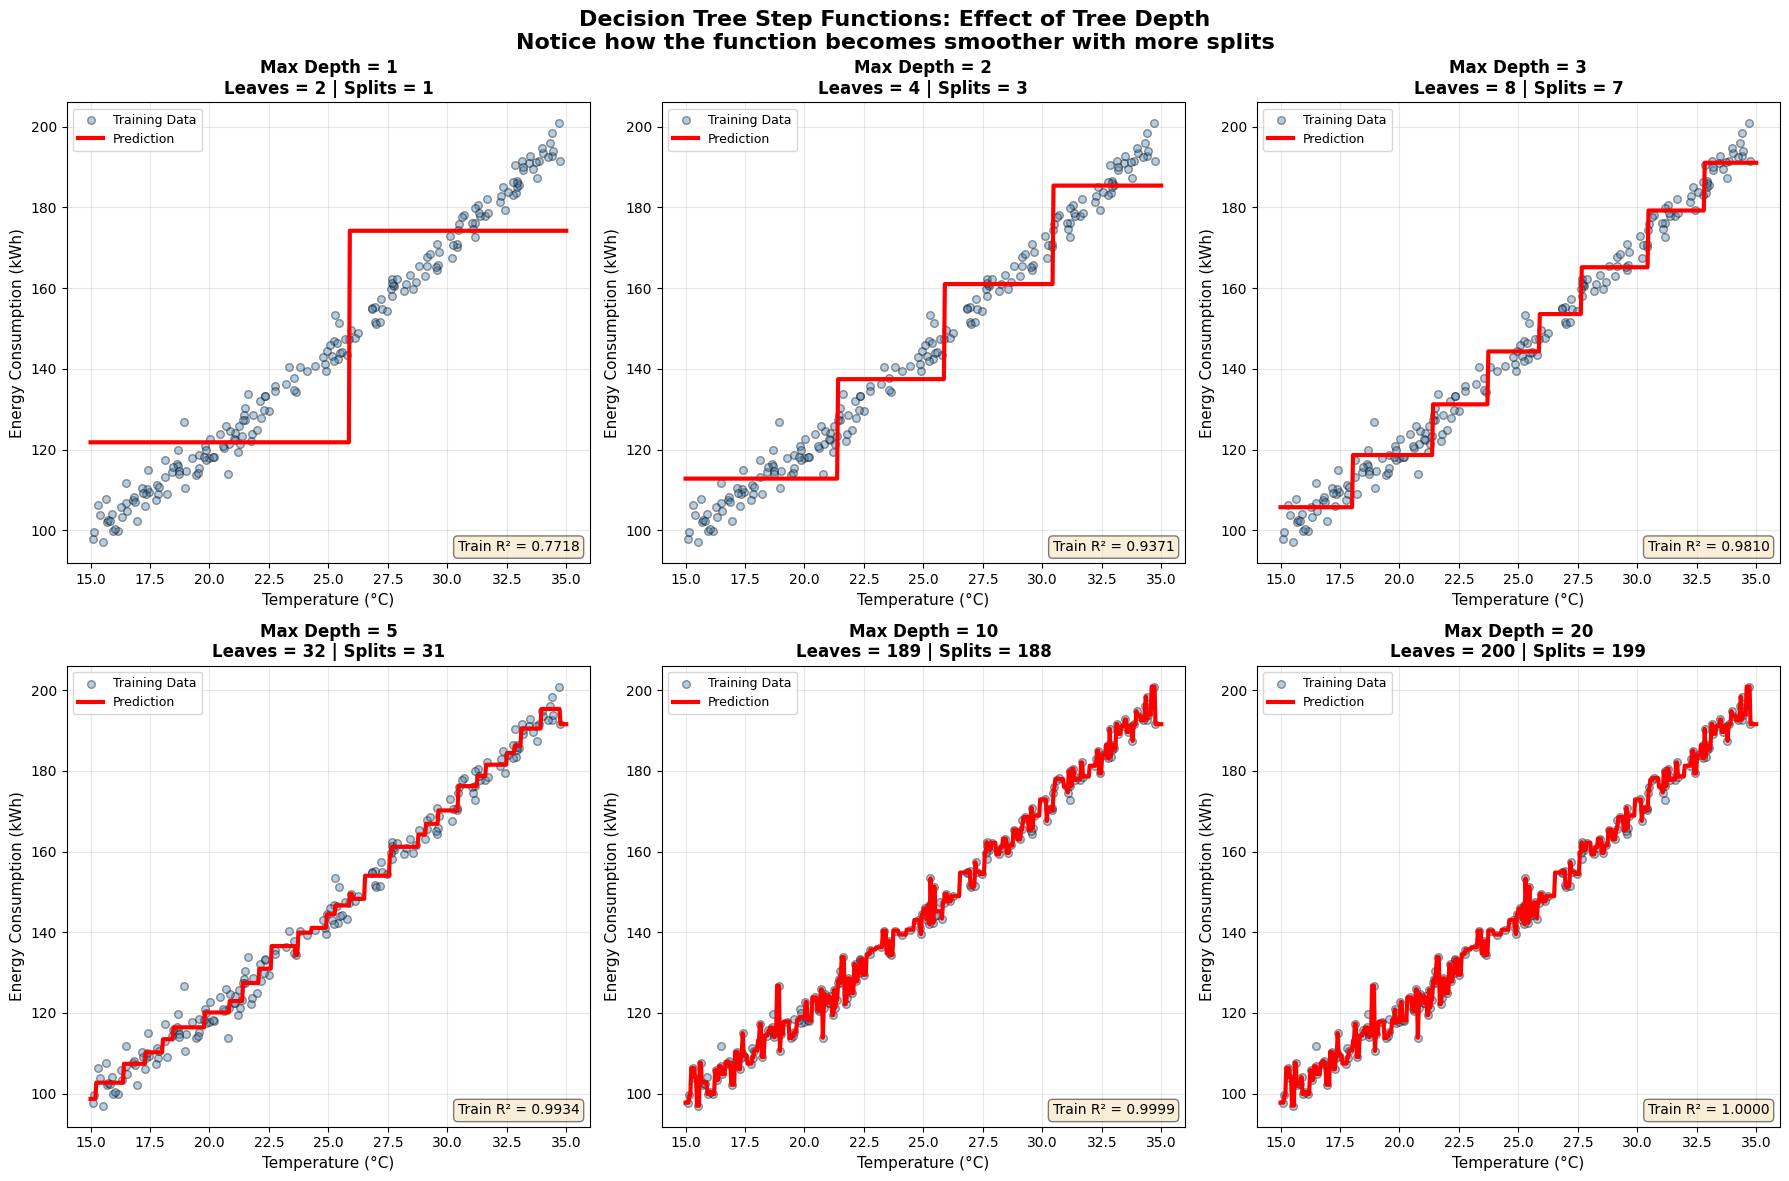


Observations:
------------------------------------------------------------
• Depth 1: Creates 2 leaves → 1 split → Very simple step function
• Depth 2: Creates 4 leaves → 3 splits → Slightly smoother
• Depth 3: Creates 8 leaves → 7 splits → More adaptive
• Depth 5: Creates 32 leaves → 31 splits → Much smoother
• Depth 10+: Many leaves → Many splits → Very smooth (but may overfit)

Key Insight:
→ More splits = more leaves = smoother approximation of the true function
→ But too many splits leads to overfitting (memorizing noise)


In [18]:
print("\n" + "="*60)
print("DECISION TREE STEP FUNCTIONS - HOW PREDICTIONS CHANGE")
print("="*60)

np.random.seed(42)
X_simple = np.random.uniform(15, 35, 200).reshape(-1, 1)
y_simple = 50 + 2.5 * X_simple.ravel() + 0.05 * X_simple.ravel()**2 + np.random.normal(0, 3, 200)

X_grid = np.linspace(15, 35, 500).reshape(-1, 1)

depths = [1, 2, 3, 5, 10, 20]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, depth in enumerate(depths):
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_simple, y_simple)
    
    y_pred = dt.predict(X_grid)
    
    axes[idx].scatter(X_simple, y_simple, alpha=0.4, s=30, c='steelblue', 
                     edgecolors='black', label='Training Data', zorder=2)
    axes[idx].plot(X_grid, y_pred, 'r-', linewidth=3, label='Prediction', zorder=3)
    axes[idx].set_xlabel('Temperature (°C)', fontsize=11)
    axes[idx].set_ylabel('Energy Consumption (kWh)', fontsize=11)
    axes[idx].set_title(f'Max Depth = {depth}\nLeaves = {dt.get_n_leaves()} | Splits = {dt.get_n_leaves() - 1}', 
                       fontsize=12, fontweight='bold')
    axes[idx].legend(loc='upper left', fontsize=9)
    axes[idx].grid(alpha=0.3)
    
    r2 = r2_score(y_simple, dt.predict(X_simple))
    axes[idx].text(0.98, 0.02, f'Train R² = {r2:.4f}', 
                  transform=axes[idx].transAxes,
                  fontsize=10, verticalalignment='bottom', horizontalalignment='right',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Decision Tree Step Functions: Effect of Tree Depth\nNotice how the function becomes smoother with more splits', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nObservations:")
print("-" * 60)
print("• Depth 1: Creates 2 leaves → 1 split → Very simple step function")
print("• Depth 2: Creates 4 leaves → 3 splits → Slightly smoother")
print("• Depth 3: Creates 8 leaves → 7 splits → More adaptive")
print("• Depth 5: Creates 32 leaves → 31 splits → Much smoother")
print("• Depth 10+: Many leaves → Many splits → Very smooth (but may overfit)")
print("\nKey Insight:")
print("→ More splits = more leaves = smoother approximation of the true function")
print("→ But too many splits leads to overfitting (memorizing noise)")


2D DECISION BOUNDARIES - STEP FUNCTIONS IN 2 DIMENSIONS


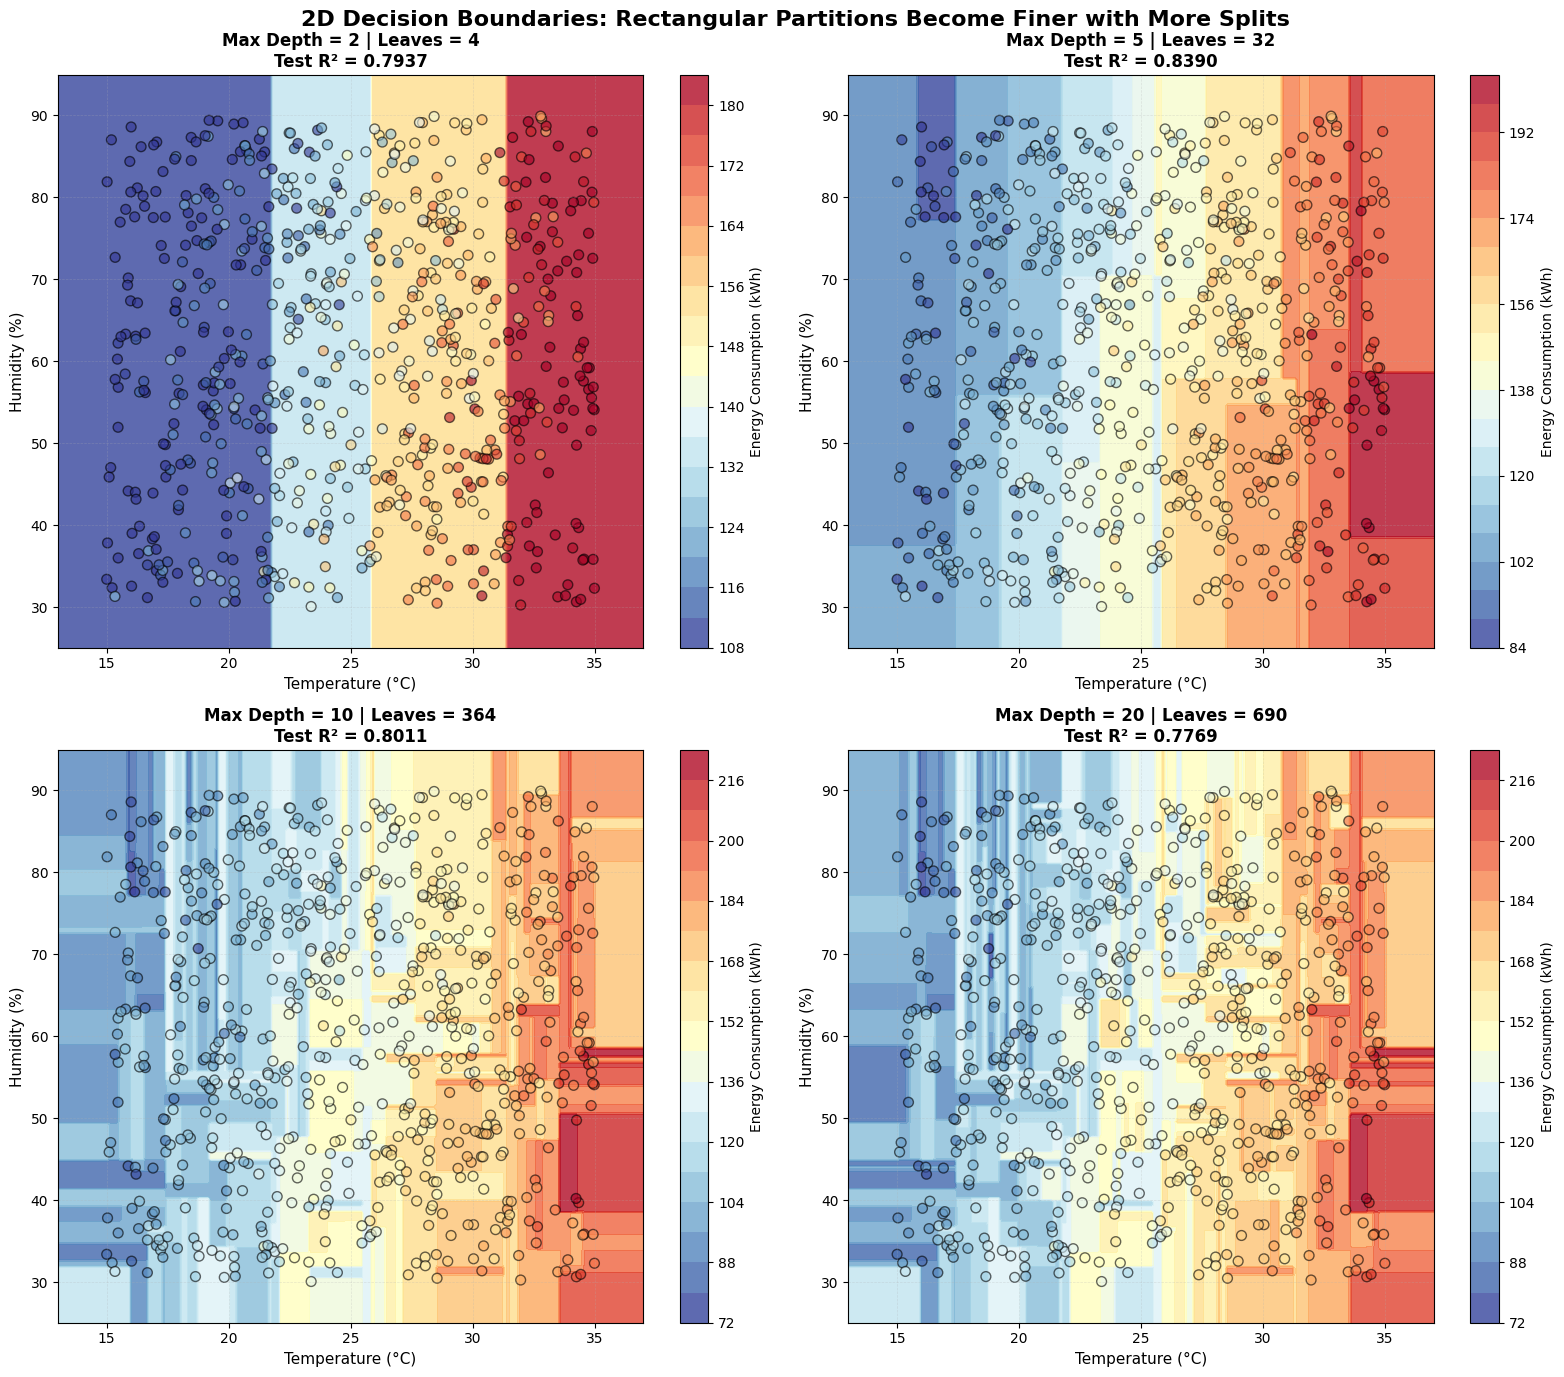


Observations in 2D:
------------------------------------------------------------
• Depth 2: Large rectangular regions → Few splits → Blocky predictions
• Depth 5: Smaller rectangles → More splits → Smoother transitions
• Depth 10: Fine-grained regions → Many splits → Detailed patterns
• Depth 20: Very fine regions → Too many splits → May capture noise

Decision trees partition the feature space into axis-aligned rectangles
Each rectangle (leaf) has a constant prediction value → step function!
More leaves = smaller rectangles = smoother approximation


In [19]:
print("\n" + "="*60)
print("2D DECISION BOUNDARIES - STEP FUNCTIONS IN 2 DIMENSIONS")
print("="*60)

X_2d = data_reg[['Temperature', 'Humidity']].values
y_2d = data_reg['Energy_Consumption'].values

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d, test_size=0.3, random_state=42
)

temp_min, temp_max = X_2d[:, 0].min() - 2, X_2d[:, 0].max() + 2
hum_min, hum_max = X_2d[:, 1].min() - 5, X_2d[:, 1].max() + 5
xx, yy = np.meshgrid(np.linspace(temp_min, temp_max, 200),
                     np.linspace(hum_min, hum_max, 200))

depths_2d = [2, 5, 10, 20]
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

for idx, depth in enumerate(depths_2d):
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train_2d, y_train_2d)
    
    Z = dt.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    contour = axes[idx].contourf(xx, yy, Z, levels=20, cmap='RdYlBu_r', alpha=0.8)
    plt.colorbar(contour, ax=axes[idx], label='Energy Consumption (kWh)')
    
    scatter = axes[idx].scatter(X_train_2d[:, 0], X_train_2d[:, 1], 
                               c=y_train_2d, cmap='RdYlBu_r', 
                               edgecolors='black', s=50, alpha=0.6,
                               vmin=Z.min(), vmax=Z.max())
    
    axes[idx].set_xlabel('Temperature (°C)', fontsize=11)
    axes[idx].set_ylabel('Humidity (%)', fontsize=11)
    axes[idx].set_title(f'Max Depth = {depth} | Leaves = {dt.get_n_leaves()}\nTest R² = {r2_score(y_test_2d, dt.predict(X_test_2d)):.4f}', 
                       fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3, linestyle='--', linewidth=0.5)

plt.suptitle('2D Decision Boundaries: Rectangular Partitions Become Finer with More Splits', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nObservations in 2D:")
print("-" * 60)
print("• Depth 2: Large rectangular regions → Few splits → Blocky predictions")
print("• Depth 5: Smaller rectangles → More splits → Smoother transitions")
print("• Depth 10: Fine-grained regions → Many splits → Detailed patterns")
print("• Depth 20: Very fine regions → Too many splits → May capture noise")
print("\nDecision trees partition the feature space into axis-aligned rectangles")
print("Each rectangle (leaf) has a constant prediction value → step function!")
print("More leaves = smaller rectangles = smoother approximation")

In [20]:
print("\n" + "="*60)
print("CLASSIFICATION: RANDOM FOREST (100 TREES) vs DECISION TREE")
print("="*60)

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
dt_clf = DecisionTreeClassifier(max_depth=10, random_state=42)

rf_clf.fit(X_train_c, y_train_c)
dt_clf.fit(X_train_c, y_train_c)

y_pred_rf_clf = rf_clf.predict(X_test_c)
y_pred_dt_clf = dt_clf.predict(X_test_c)

rf_acc = accuracy_score(y_test_c, y_pred_rf_clf)
dt_acc = accuracy_score(y_test_c, y_pred_dt_clf)

print("\nClassification Performance:")
print("-" * 70)
print(f"{'Metric':<20} {'Decision Tree':<25} {'Random Forest':<25}")
print("-" * 70)
print(f"{'Test Accuracy':<20} {dt_acc:<25.4f} {rf_acc:<25.4f}")
print("-" * 70)
print(f"\n✓ Random Forest Improvement:")
print(f"  • Accuracy improved by: {((rf_acc - dt_acc) / dt_acc * 100):.2f}%")


CLASSIFICATION: RANDOM FOREST (100 TREES) vs DECISION TREE

Classification Performance:
----------------------------------------------------------------------
Metric               Decision Tree             Random Forest            
----------------------------------------------------------------------
Test Accuracy        0.9415                    0.9708                   
----------------------------------------------------------------------

✓ Random Forest Improvement:
  • Accuracy improved by: 3.11%


In [21]:
print("\n" + "="*60)
print("REGRESSION: RANDOM FOREST (100 TREES) vs DECISION TREE")
print("="*60)

rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
dt_reg = DecisionTreeRegressor(max_depth=10, random_state=42)

rf_reg.fit(X_train_r, y_train_r)
dt_reg.fit(X_train_r, y_train_r)

y_pred_rf_reg = rf_reg.predict(X_test_r)
y_pred_dt_reg = dt_reg.predict(X_test_r)

rf_rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_rf_reg))
dt_rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_dt_reg))
rf_mae = mean_absolute_error(y_test_r, y_pred_rf_reg)
dt_mae = mean_absolute_error(y_test_r, y_pred_dt_reg)
rf_r2 = r2_score(y_test_r, y_pred_rf_reg)
dt_r2 = r2_score(y_test_r, y_pred_dt_reg)

print("\nRegression Performance:")
print("-" * 70)
print(f"{'Metric':<20} {'Decision Tree':<25} {'Random Forest':<25}")
print("-" * 70)
print(f"{'Test RMSE':<20} {dt_rmse:<25.4f} {rf_rmse:<25.4f}")
print(f"{'Test MAE':<20} {dt_mae:<25.4f} {rf_mae:<25.4f}")
print(f"{'Test R²':<20} {dt_r2:<25.4f} {rf_r2:<25.4f}")
print("-" * 70)
print(f"\n✓ Random Forest Improvement:")
print(f"  • RMSE reduced by: {((dt_rmse - rf_rmse) / dt_rmse * 100):.2f}%")
print(f"  • R² improved by: {((rf_r2 - dt_r2) / dt_r2 * 100):.2f}%")


REGRESSION: RANDOM FOREST (100 TREES) vs DECISION TREE

Regression Performance:
----------------------------------------------------------------------
Metric               Decision Tree             Random Forest            
----------------------------------------------------------------------
Test RMSE            10.0199                   6.8407                   
Test MAE             7.8512                    5.5666                   
Test R²              0.9159                    0.9608                   
----------------------------------------------------------------------

✓ Random Forest Improvement:
  • RMSE reduced by: 31.73%
  • R² improved by: 4.90%


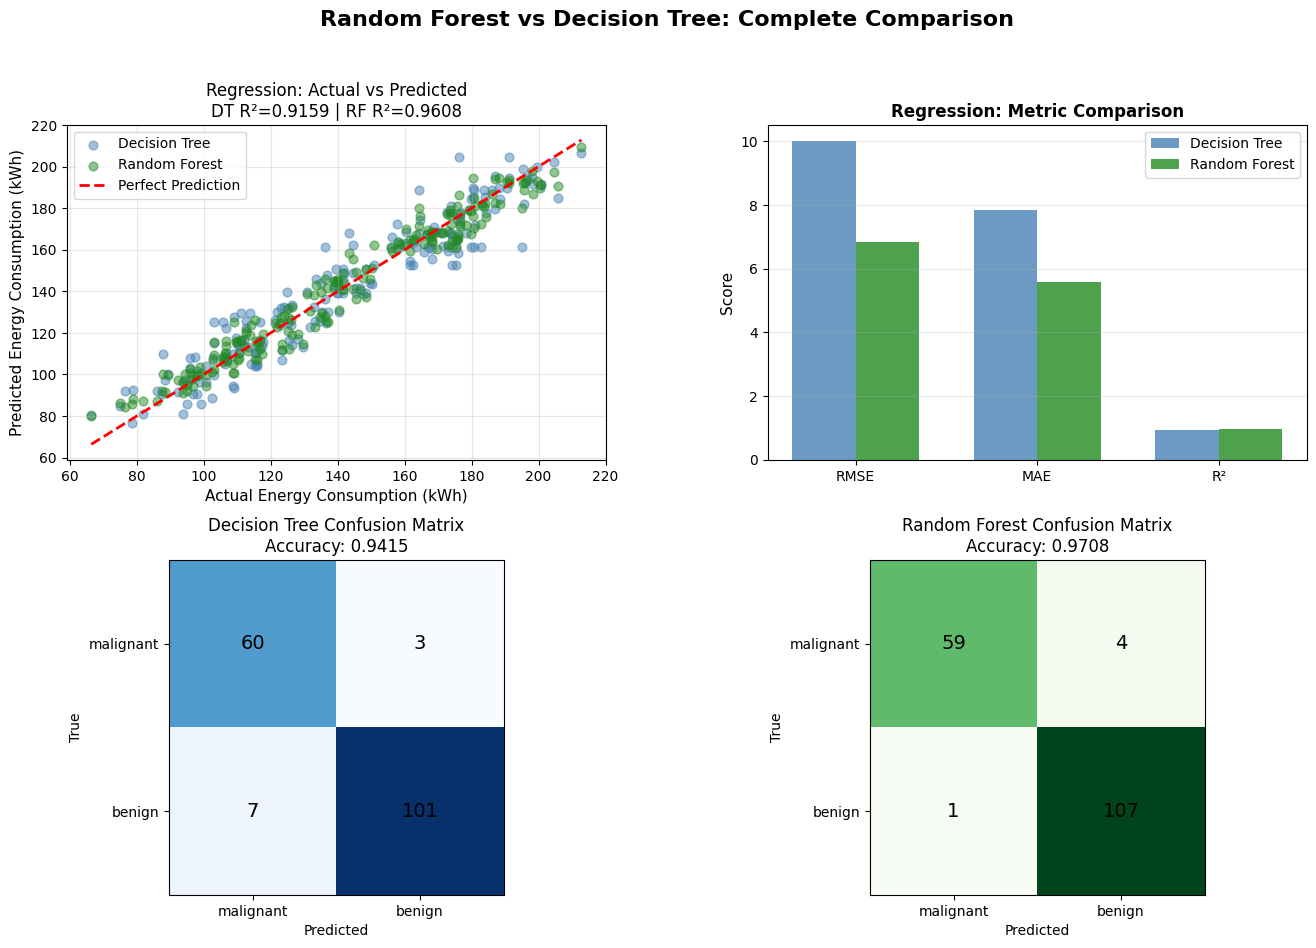

In [22]:
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test_r, y_pred_dt_reg, alpha=0.5, c='steelblue', label='Decision Tree', s=40)
ax1.scatter(y_test_r, y_pred_rf_reg, alpha=0.5, c='forestgreen', label='Random Forest', s=40)
ax1.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Energy Consumption (kWh)', fontsize=11)
ax1.set_ylabel('Predicted Energy Consumption (kWh)', fontsize=11)
ax1.set_title(f'Regression: Actual vs Predicted\nDT R²={dt_r2:.4f} | RF R²={rf_r2:.4f}', fontsize=12)
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
metrics = ['RMSE', 'MAE', 'R²']
dt_values = [dt_rmse, dt_mae, dt_r2]
rf_values = [rf_rmse, rf_mae, rf_r2]
x = np.arange(len(metrics))
width = 0.35
ax2.bar(x - width/2, dt_values, width, label='Decision Tree', color='steelblue', alpha=0.8)
ax2.bar(x + width/2, rf_values, width, label='Random Forest', color='forestgreen', alpha=0.8)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Regression: Metric Comparison', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

cm_dt_clf = confusion_matrix(y_test_c, y_pred_dt_clf)
cm_rf_clf = confusion_matrix(y_test_c, y_pred_rf_clf)

ax3 = fig.add_subplot(gs[1, 0])
im3 = ax3.imshow(cm_dt_clf, interpolation='nearest', cmap=plt.cm.Blues)
ax3.set(xticks=np.arange(2), yticks=np.arange(2),
        xticklabels=cancer.target_names, yticklabels=cancer.target_names,
        ylabel='True', xlabel='Predicted',
        title=f'Decision Tree Confusion Matrix\nAccuracy: {dt_acc:.4f}')
for i in range(2):
    for j in range(2):
        ax3.text(j, i, format(cm_dt_clf[i, j], 'd'),
                ha="center", va="center", fontsize=14)

ax4 = fig.add_subplot(gs[1, 1])
im4 = ax4.imshow(cm_rf_clf, interpolation='nearest', cmap=plt.cm.Greens)
ax4.set(xticks=np.arange(2), yticks=np.arange(2),
        xticklabels=cancer.target_names, yticklabels=cancer.target_names,
        ylabel='True', xlabel='Predicted',
        title=f'Random Forest Confusion Matrix\nAccuracy: {rf_acc:.4f}')
for i in range(2):
    for j in range(2):
        ax4.text(j, i, format(cm_rf_clf[i, j], 'd'),
                ha="center", va="center", fontsize=14)

plt.suptitle('Random Forest vs Decision Tree: Complete Comparison', 
             fontsize=16, fontweight='bold', y=0.995)
plt.show()